# Salary Prediction — Pre-Modeling Preprocessing Audit

**Purpose:** Inspect the TRAINING split only and make evidence-based
feature/preprocessing decisions for the salary prediction pipeline.

**This notebook does NOT:**
- Train the final model
- Tune hyperparameters
- Fit any production preprocessing artifact
- Touch `validation.parquet` or `test.parquet`

All conclusions below are derived strictly from `train.parquet` and are
labeled as **evidence-supported**, **tentative**, or **requires validation
ablation** wherever appropriate.

## Setup

Standard imports, display options, and a fixed random state so every
diagnostic in this notebook is reproducible.

In [1]:
import json
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 180)

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")

# TRAIN_PATH = Path("artifacts/salary_dataset_splits/latest/train.parquet")
# VAL_PATH = Path("artifacts/salary_dataset_splits/latest/validation.parquet")   # NEVER LOADED HERE
# TEST_PATH = Path("artifacts/salary_dataset_splits/latest/test.parquet")        # NEVER LOADED HERE

# print("Train path :", TRAIN_PATH.resolve())
print("Random state:", RANDOM_STATE)

Random state: 42


---
## Section 1 — Load Training Data Only

**What:** Load `train.parquet` exclusively and confirm its basic shape,
schema, and the presence of both target columns.

**Why:** Every decision in this notebook must come from the training
partition alone. Accidentally including validation/test data at the
feature-selection stage would leak information into modeling decisions
made "before" model comparison, defeating the purpose of the split.

**Effect on future model:** Establishes the row/column universe every
later section will operate on, and guarantees the two targets exist and
are complete before we do anything else.

In [2]:
# assert TRAIN_PATH.exists(), (
#     f"Training file not found at {TRAIN_PATH}. "
#     "This notebook must only be run against the training split."
# )

train = pd.read_parquet('/content/train.parquet')

print(f"Shape            : {train.shape}")
print(f"Row count        : {train.shape[0]:,}")
print(f"Column count     : {train.shape[1]}")
print()
print("Columns:")
for c in train.columns:
    print(f"  - {c} ({train[c].dtype})")

Shape            : (33708, 23)
Row count        : 33,708
Column count     : 23

Columns:
  - target_annual_salary (float64)
  - target_log_salary (float64)
  - salary_target_source (string)
  - title (object)
  - formatted_experience_level (category)
  - formatted_work_type (category)
  - company_state (category)
  - company_country (category)
  - company_size (category)
  - company_employee_count (Int64)
  - company_follower_count (Int64)
  - top_industry (string)
  - top_skill (string)
  - skill_list (object)
  - skill_count (int64)
  - log_company_employee_count (Float64)
  - log_company_follower_count (Float64)
  - posting_group_id (object)
  - company_name (object)
  - location (object)
  - original_listed_time (datetime64[ns])
  - listed_time (datetime64[ns])
  - dataset_version (object)


In [3]:
REQUIRED_TARGETS = ["target_annual_salary", "target_log_salary"]
for t in REQUIRED_TARGETS:
    assert t in train.columns, f"Missing required target column: {t}"

assert train["target_annual_salary"].isna().sum() == 0, "target_annual_salary has missing values"
assert train["target_log_salary"].isna().sum() == 0, "target_log_salary has missing values"

assert "posting_group_id" in train.columns, "posting_group_id missing — group-aware split cannot be verified"

print("Target integrity checks passed: no missing target values.")
print()
print(f"Training rows          : {len(train):,}")
print(f"Unique posting groups   : {train['posting_group_id'].nunique():,}")
print(f"Avg rows per group      : {len(train) / train['posting_group_id'].nunique():.2f}")

Target integrity checks passed: no missing target values.

Training rows          : 33,708
Unique posting groups   : 32,593
Avg rows per group      : 1.03


**Interpretation guidance:** If `unique posting groups` is close to
`training rows`, groups are mostly singletons and the group-aware split
is behaving similarly to a row-level split. If it's much smaller,
related postings are meaningfully clustered — good, since that's exactly
what `GroupShuffleSplit` on `posting_group_id` is meant to protect
against leaking across partitions.

---
## Section 2 — Feature Role Inventory

**What:** Declare the *expected* role of every candidate column (text,
categorical, numeric, metadata, target) and check which of them actually
exist in the loaded training data.

**Why:** The upstream feature engineering stage is allowed to evolve.
This section makes no assumption that every "expected" column is
present — it reports reality, not the spec.

**Effect on future model:** Produces the master feature-role table that
every later section references.

In [4]:
TEXT_CANDIDATES = ["title", "skill_list"]

CATEGORICAL_CANDIDATES = [
    "formatted_experience_level",
    "formatted_work_type",
    "company_state",
    "company_country",
    "company_size",
    "top_industry",
    "top_skill",
]

NUMERIC_CANDIDATES = [
    "company_employee_count",
    "company_follower_count",
    "skill_count",
    "log_company_employee_count",
    "log_company_follower_count",
]

METADATA = [
    "company_name",
    "location",
    "original_listed_time",
    "listed_time",
    "dataset_version",
    "posting_group_id",
    "salary_target_source",
]

TARGETS = ["target_annual_salary", "target_log_salary"]

ALL_EXPECTED = {
    "TEXT": TEXT_CANDIDATES,
    "CATEGORICAL": CATEGORICAL_CANDIDATES,
    "NUMERIC": NUMERIC_CANDIDATES,
    "METADATA": METADATA,
    "TARGET": TARGETS,
}

rows = []
for role, cols in ALL_EXPECTED.items():
    for c in cols:
        exists = c in train.columns
        if exists:
            s = train[c]
            missing_count = int(s.isna().sum())
            missing_pct = round(100 * missing_count / len(train), 2)
            nunique = int(s.nunique(dropna=True))
            unique_ratio = round(nunique / len(train), 4)
            dtype = str(s.dtype)
        else:
            missing_count = missing_pct = nunique = unique_ratio = np.nan
            dtype = None
        rows.append({
            "feature": c,
            "expected_role": role,
            "exists": exists,
            "dtype": dtype,
            "missing_count": missing_count,
            "missing_pct": missing_pct,
            "nunique": nunique,
            "unique_ratio": unique_ratio,
        })

feature_inventory = pd.DataFrame(rows)
feature_inventory

,feature,expected_role,exists,dtype,missing_count,missing_pct,nunique,unique_ratio
0,title,TEXT,True,object,0,0.00,22953,0.6809
1,skill_list,TEXT,True,object,471,1.40,1417,0.0420
2,formatted_experience_level,CATEGORICAL,True,category,0,0.00,7,0.0002
3,formatted_work_type,CATEGORICAL,True,category,0,0.00,7,0.0002
4,company_state,CATEGORICAL,True,category,0,0.00,340,0.0101
5,company_country,CATEGORICAL,True,category,0,0.00,44,0.0013
6,company_size,CATEGORICAL,True,category,0,0.00,8,0.0002
7,top_industry,CATEGORICAL,True,string,22,0.07,332,0.0098
8,top_skill,CATEGORICAL,True,string,0,0.00,35,0.0010
9,company_employee_count,NUMERIC,True,Int64,0,0.00,4298,0.1275


In [5]:
missing_expected = feature_inventory.loc[~feature_inventory["exists"], "feature"].tolist()
if missing_expected:
    print("Expected columns NOT found in train.parquet (reported, not fatal):")
    for c in missing_expected:
        print(f"  - {c}")
else:
    print("All expected candidate columns are present in the training data.")

All expected candidate columns are present in the training data.


**Interpretation guidance:** Any row with `exists = False` simply means
that candidate is unavailable right now — downstream sections will skip
it gracefully rather than fail. A high `unique_ratio` on a categorical
candidate is an early cardinality warning we'll quantify in Section 9.

---
## Section 3 — Global Missingness Audit

**What:** Missingness (count, %, non-null count) for every candidate
predictor, sorted worst-to-best, with a simple LOW/MODERATE/HIGH/VERY
HIGH classification band.

**Why:** Missingness affects imputation strategy, whether a feature can
be a *required* product input, and whether "missing" itself might be
informative (e.g., missing `company_size` may correlate with small/young
companies).

**Effect on future model:** Feeds directly into Section 25's
transformation table (median imputation vs. "missing" category vs. drop).

**Note:** thresholds below are for *classification/reporting only* — no
feature is dropped automatically based on missingness alone.

In [6]:
candidate_cols = TEXT_CANDIDATES + CATEGORICAL_CANDIDATES + NUMERIC_CANDIDATES
candidate_cols = [c for c in candidate_cols if c in train.columns]

miss = pd.DataFrame({
    "missing_count": train[candidate_cols].isna().sum(),
    "non_null_count": train[candidate_cols].notna().sum(),
})
miss["missing_percentage"] = (100 * miss["missing_count"] / len(train)).round(2)
miss = miss.sort_values("missing_percentage", ascending=False)

def band(pct):
    if pct < 5:
        return "LOW"
    elif pct < 20:
        return "MODERATE"
    elif pct < 50:
        return "HIGH"
    else:
        return "VERY HIGH"

miss["missingness_band"] = miss["missing_percentage"].apply(band)
miss

,missing_count,non_null_count,missing_percentage,missingness_band
skill_list,471,33237,1.40,LOW
top_industry,22,33686,0.07,LOW
formatted_experience_level,0,33708,0.00,LOW
formatted_work_type,0,33708,0.00,LOW
company_state,0,33708,0.00,LOW
title,0,33708,0.00,LOW
company_country,0,33708,0.00,LOW
company_size,0,33708,0.00,LOW
top_skill,0,33708,0.00,LOW
company_employee_count,0,33708,0.00,LOW


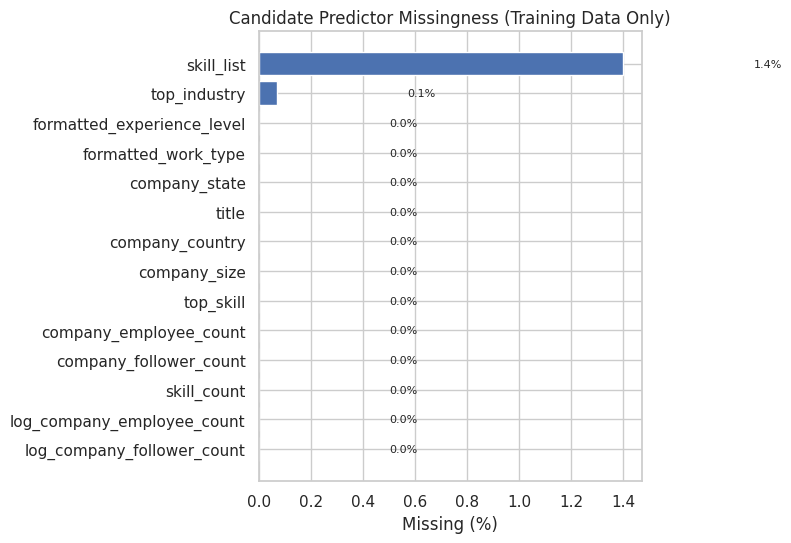

In [7]:
fig, ax = plt.subplots(figsize=(9, max(3, 0.4 * len(miss))))
colors = miss["missingness_band"].map({
    "LOW": "#4C72B0", "MODERATE": "#DD8452", "HIGH": "#C44E52", "VERY HIGH": "#8C0800"
})
ax.barh(miss.index[::-1], miss["missing_percentage"][::-1], color=colors[::-1])
ax.set_xlabel("Missing (%)")
ax.set_title("Candidate Predictor Missingness (Training Data Only)")
for i, (idx, v) in enumerate(miss["missing_percentage"][::-1].items()):
    ax.text(v + 0.5, i, f"{v:.1f}%", va="center", fontsize=8)
plt.tight_layout()
plt.show()

In [8]:
watchlist = [
    "formatted_experience_level", "company_state", "company_country",
    "company_size", "top_industry", "top_skill", "skill_list",
    "company_employee_count", "company_follower_count",
]
watchlist = [c for c in watchlist if c in miss.index]
miss.loc[watchlist]

,missing_count,non_null_count,missing_percentage,missingness_band
formatted_experience_level,0,33708,0.00,LOW
company_state,0,33708,0.00,LOW
company_country,0,33708,0.00,LOW
company_size,0,33708,0.00,LOW
top_industry,22,33686,0.07,LOW
top_skill,0,33708,0.00,LOW
skill_list,471,33237,1.40,LOW
company_employee_count,0,33708,0.00,LOW
company_follower_count,0,33708,0.00,LOW


**Interpretation guidance:** A `VERY HIGH` band is a flag to inspect, not
a verdict. Three follow-up questions decide the outcome: (1) can the
product realistically collect this at inference time anyway, (2) is
missingness itself correlated with salary (informative missingness), and
(3) does the feature add signal beyond what's already captured elsewhere.
Sections 9–17 answer these per-feature.

---
## Section 4 — Target Sanity Check

**What:** Distributional summary (mean/median/std/percentiles/skew) and
histograms for `target_annual_salary` and `target_log_salary`.

**Why:** Confirms the upstream salary feature engineering stage produced
a sane target *after* the group-aware split — e.g., no accidental
truncation, no negative salaries, no degenerate constant column.

**Effect on future model:** Validates the premise for using
`target_log_salary` as the modeling target (skew reduction) and
`target_annual_salary` for dollar-space evaluation (MAE/RMSE).

In [9]:
def target_summary(s: pd.Series) -> pd.Series:
    return pd.Series({
        "count": s.count(),
        "mean": s.mean(),
        "median": s.median(),
        "std": s.std(),
        "min": s.min(),
        "P1": s.quantile(0.01),
        "P5": s.quantile(0.05),
        "P25": s.quantile(0.25),
        "P50": s.quantile(0.50),
        "P75": s.quantile(0.75),
        "P95": s.quantile(0.95),
        "P99": s.quantile(0.99),
        "max": s.max(),
        "skewness": stats.skew(s.dropna()),
    })

target_stats = pd.DataFrame({
    "target_annual_salary": target_summary(train["target_annual_salary"]),
    "target_log_salary": target_summary(train["target_log_salary"]),
})
target_stats.round(3)

,target_annual_salary,target_log_salary
count,33708.000,33708.000
mean,96594.779,11.318
median,82500.000,11.321
std,60830.784,0.563
min,10000.000,9.210
P1,27040.000,10.205
P5,34320.000,10.444
P25,52500.000,10.869
P50,82500.000,11.321
P75,125000.000,11.736


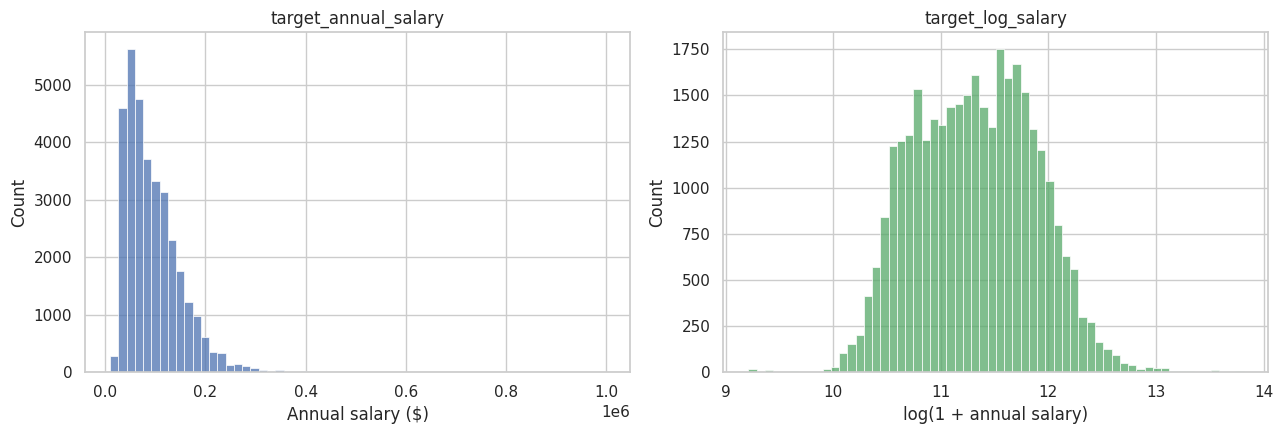

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(train["target_annual_salary"], bins=60, ax=axes[0], color="#4C72B0")
axes[0].set_title("target_annual_salary")
axes[0].set_xlabel("Annual salary ($)")

sns.histplot(train["target_log_salary"], bins=60, ax=axes[1], color="#55A868")
axes[1].set_title("target_log_salary")
axes[1].set_xlabel("log(1 + annual salary)")

plt.tight_layout()
plt.show()

**Interpretation guidance:** Expect `target_annual_salary` to show
positive (right) skew and `target_log_salary` to look substantially more
symmetric/bell-shaped — that's the evidence supporting the planned use of
`target_log_salary` as the Ridge regression target, with predictions
converted back to dollars via `np.expm1`. If the log target still shows
strong skew or multiple modes, that's worth flagging before modeling
(but this notebook does not redesign target construction unless a
serious problem is found).

---
## Section 5 — Text Feature Audit: Job Title

**What:** Missingness/cardinality, character/word-length distribution,
most common raw titles, a *non-destructive* normalized-title comparison,
and salary cuts by common seniority/role tokens.

**Why:** `title` is the single most product-realistic input a user will
provide. We need to know if it carries real salary signal (supporting
TF-IDF) before investing in title vectorization.

**Effect on future model:** Directly informs Section 6 (TF-IDF
readiness) and the Baseline 2/3 modeling plan.

In [11]:
title_col = "title"
assert title_col in train.columns, "title column not found"

t = train[title_col]
print(f"missing_count : {t.isna().sum()}")
print(f"missing_pct   : {100*t.isna().mean():.2f}%")
print(f"nunique       : {t.nunique(dropna=True):,}")
print(f"unique_ratio  : {t.nunique(dropna=True)/len(t):.4f}")

missing_count : 0
missing_pct   : 0.00%
nunique       : 22,953
unique_ratio  : 0.6809


In [12]:
title_nonnull = t.dropna().astype(str)
char_len = title_nonnull.str.len()
word_count = title_nonnull.str.split().apply(len)

text_stats = pd.DataFrame({
    "char_length": [char_len.mean(), char_len.median(), char_len.quantile(0.95), char_len.quantile(0.99), char_len.max()],
    "word_count": [word_count.mean(), word_count.median(), word_count.quantile(0.95), word_count.quantile(0.99), word_count.max()],
}, index=["mean", "median", "P95", "P99", "max"])
text_stats.round(2)

,char_length,word_count
mean,31.35,4.14
median,28.00,3.00
P95,62.00,9.00
P99,83.00,13.00
max,200.00,30.00


In [13]:
print("Top 20 most common exact titles:")
title_nonnull.value_counts().head(20).to_frame("count")

Top 20 most common exact titles:


,count
title,
Senior Accountant,131
Project Manager,110
Staff Accountant,102
Administrative Assistant,101
Controller,93
Customer Service Representative,92
Sales Manager,85
Retail Sales Associate,80
Executive Assistant,77


In [14]:
# Analysis-only normalization -- does NOT overwrite the original column
normalized_title = (
    title_nonnull
    .str.lower()
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

print(f"Raw unique titles        : {title_nonnull.nunique():,}")
print(f"Normalized unique titles : {normalized_title.nunique():,}")
print(f"Reduction                : {100*(1 - normalized_title.nunique()/title_nonnull.nunique()):.2f}%")

Raw unique titles        : 22,953
Normalized unique titles : 22,876
Reduction                : 0.34%


In [15]:
TOKENS = [
    "senior", "sr", "junior", "jr", "lead", "principal", "staff", "manager",
    "director", "vp", "vice president", "intern", "entry", "associate",
    "engineer", "developer", "scientist", "analyst",
]

MIN_SUPPORT = 30
rows = []
norm_titles = normalized_title
salaries = train.loc[title_nonnull.index, "target_annual_salary"]

for tok in TOKENS:
    mask = norm_titles.str.contains(rf"\b{re.escape(tok)}\b", regex=True, na=False)
    n = int(mask.sum())
    if n >= MIN_SUPPORT:
        sal = salaries[mask.values]
        rows.append({
            "token": tok,
            "posting_count": n,
            "median_annual_salary": sal.median(),
            "mean_annual_salary": sal.mean(),
        })

token_salary = pd.DataFrame(rows).sort_values("median_annual_salary", ascending=False)
print(f"(Tokens with fewer than {MIN_SUPPORT} matches are omitted -- insufficient sample size)")
token_salary.round(0)

(Tokens with fewer than 30 matches are omitted -- insufficient sample size)


,token,posting_count,median_annual_salary,mean_annual_salary
8,vp,101,187500.0,195040.0
9,vice president,189,184500.0,208009.0
4,principal,260,171589.0,174477.0
7,director,1413,160000.0,163967.0
15,scientist,253,132250.0,134373.0
1,sr,739,130000.0,134216.0
14,developer,481,127500.0,130485.0
0,senior,2834,125000.0,134436.0
13,engineer,3008,124800.0,131162.0
3,lead,803,112300.0,114674.0


**Interpretation guidance:** These are simple group medians, **not
causal estimates** — "principal"/"director" titles pulling higher medians
than "intern"/"entry" is expected and reassuring (title correlates with
seniority which correlates with pay), but token co-occurrence with
industry/experience confounds this. The key takeaway for feature
selection is qualitative: if token cuts show *any* meaningful salary
separation, `title` carries usable signal and is a strong TF-IDF
candidate — evaluated quantitatively in Section 6.

---
## Section 6 — Title N-gram / TF-IDF Readiness Audit

**What:** Fit a *diagnostic-only* `TfidfVectorizer` on training titles to
inspect vocabulary size, matrix shape/sparsity, and how vocabulary size
responds to `min_df`.

**Why:** Before committing to TF-IDF(title) in Baseline 2, we need to
know whether the resulting matrix is a computationally reasonable size
for a sparse Ridge pipeline.

**Effect on future model:** Informs the approximate `min_df`/`max_df`
configuration to *try* later — this vectorizer is discarded, not saved
as a production artifact.

In [16]:
from sklearn.feature_extraction.text import TfidfVectorizer

diagnostic_vectorizer = TfidfVectorizer(
    lowercase=True,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.95,
    sublinear_tf=True,
)

title_corpus = title_nonnull.tolist()
X_title_diag = diagnostic_vectorizer.fit_transform(title_corpus)

vocab_size = len(diagnostic_vectorizer.vocabulary_)
n_docs, n_terms = X_title_diag.shape
sparsity = 1 - (X_title_diag.nnz / (n_docs * n_terms))

print(f"Vocabulary size : {vocab_size:,}")
print(f"Matrix shape    : {X_title_diag.shape}")
print(f"Non-zero entries: {X_title_diag.nnz:,}")
print(f"Sparsity        : {sparsity:.5%}")

Vocabulary size : 5,122
Matrix shape    : (33708, 5122)
Non-zero entries: 169,749
Sparsity        : 99.90168%


In [17]:
# Representative terms: highest mean TF-IDF weight across the corpus
mean_tfidf = np.asarray(X_title_diag.mean(axis=0)).ravel()
terms = np.array(diagnostic_vectorizer.get_feature_names_out())
top_idx = mean_tfidf.argsort()[::-1][:25]
pd.DataFrame({"term": terms[top_idx], "mean_tfidf_weight": mean_tfidf[top_idx]}).round(5)

,term,mean_tfidf_weight
0,manager,0.03587
1,engineer,0.02427
2,senior,0.02067
3,sales,0.01745
4,specialist,0.01729
5,assistant,0.01636
6,associate,0.01574
7,analyst,0.01552
8,technician,0.01351
9,director,0.01255


In [18]:
# Vocabulary sensitivity to min_df (diagnostics only, NOT tuning)
for md_val in [2, 5, 10]:
    vec = TfidfVectorizer(lowercase=True, ngram_range=(1, 2), min_df=md_val, max_df=0.95)
    vec.fit(title_corpus)
    print(f"min_df={md_val:>2} -> vocabulary size = {len(vec.vocabulary_):,}")

del diagnostic_vectorizer, X_title_diag  # discard diagnostic artifact

min_df= 2 -> vocabulary size = 15,692
min_df= 5 -> vocabulary size = 5,122
min_df=10 -> vocabulary size = 2,567


**Interpretation guidance:** A vocabulary in the low-to-mid thousands
with sparsity above ~99.5% is normal and comfortably handled by a sparse
Ridge pipeline. If `min_df=2` explodes vocabulary size dramatically
relative to `min_df=5/10`, that's a sign of long-tail rare tokens
(typos, unusual titles) that argue for `min_df >= 5` in the real
pipeline — a decision to *validate*, not finalize, here.

---
## Section 7 — skill_list Audit

**What:** Determine the actual representation of `skill_list` (Python
list, stringified list, delimiter-separated string, or free text),
inspect missingness/cardinality, and identify a suitable sparse
representation for a Ridge-first modeling strategy.

**Why:** Skills are a realistic, high-signal user input, but the right
encoding (TF-IDF vs. `MultiLabelBinarizer` vs. simple tokens) depends
entirely on how the column is actually stored.

**Effect on future model:** Determines the skill representation used in
Baseline 3.

In [19]:
skill_col = "skill_list"
has_skill_list = skill_col in train.columns
if has_skill_list:
    sample_vals = train[skill_col].dropna().head(5).tolist()
    print("Sample skill_list values (raw):")
    for v in sample_vals:
        print(f"  type={type(v).__name__!r:12} value={v!r}"[:200])
else:
    print("skill_list column not present in training data.")

Sample skill_list values (raw):
  type='str'        value='OTHER'
  type='str'        value='MANAGEMENT|MANUFACTURING'
  type='str'        value='INFORMATION_TECHNOLOGY'
  type='str'        value='MANAGEMENT|MANUFACTURING'
  type='str'        value='ANALYST|INFORMATION_TECHNOLOGY|RESEARCH'


In [20]:
if has_skill_list:
    s = train[skill_col]
    missing_pct = 100 * s.isna().mean()
    nonnull = s.dropna()

    def to_token_list(v):
        if isinstance(v, (list, np.ndarray)):
            return [str(x).strip() for x in v if str(x).strip()]
        if isinstance(v, str):
            txt = v.strip()
            if txt.startswith("[") and txt.endswith("]"):
                inner = txt[1:-1]
                parts = re.split(r"','|", "|","|', '", inner)
                parts = [p.strip(" '\"") for p in parts]
                return [p for p in parts if p]
            parts = re.split(r"[,;|]", txt)
            return [p.strip() for p in parts if p.strip()]
        return []

    parsed = nonnull.apply(to_token_list)
    skills_per_posting = parsed.apply(len)
    parse_reliable = (skills_per_posting > 0).mean() > 0.5

    print(f"missing_pct              : {missing_pct:.2f}%")
    print(f"unique raw values        : {s.nunique(dropna=True):,}")
    print(f"avg text length (chars)  : {nonnull.astype(str).str.len().mean():.1f}")
    print(f"parse looks reliable     : {parse_reliable}")
    if parse_reliable:
        print(f"approx skills/posting    : mean={skills_per_posting.mean():.2f}, "
              f"median={skills_per_posting.median():.0f}, P95={skills_per_posting.quantile(0.95):.0f}")
else:
    parsed = None
    parse_reliable = False

missing_pct              : 1.40%
unique raw values        : 1,417
avg text length (chars)  : 23.1
parse looks reliable     : True
approx skills/posting    : mean=1.73, median=2, P95=3


In [21]:
if has_skill_list and parse_reliable:
    print("Representation recommendation:")
    print("  A. TF-IDF on joined tokens        -> suitable, and consistent with Ridge-first plan")
    print("  B. MultiLabelBinarizer            -> suitable if vocabulary is bounded; check cardinality below")
    print("  C. token/category representation  -> viable fallback")
    all_skills = pd.Series([tok for lst in parsed for tok in lst])
    print(f"\nDistinct skill tokens across training data: {all_skills.nunique():,}")
else:
    print("Skipping representation recommendation -- parsing was not reliable enough to trust conclusions.")

Representation recommendation:
  A. TF-IDF on joined tokens        -> suitable, and consistent with Ridge-first plan
  B. MultiLabelBinarizer            -> suitable if vocabulary is bounded; check cardinality below
  C. token/category representation  -> viable fallback

Distinct skill tokens across training data: 35


In [22]:
if has_skill_list and parse_reliable:
    MIN_SUPPORT = 30
    top_tokens = all_skills.value_counts()
    top_tokens = top_tokens[top_tokens >= MIN_SUPPORT].head(15)

    idx_map = {}
    for post_idx, lst in parsed.items():
        for tok in set(lst):
            idx_map.setdefault(tok, []).append(post_idx)

    rows = []
    for tok in top_tokens.index:
        idxs = idx_map.get(tok, [])
        sal = train.loc[idxs, "target_annual_salary"]
        rows.append({"skill": tok, "posting_count": len(idxs), "median_salary": sal.median()})

    skill_salary = pd.DataFrame(rows).sort_values("median_salary", ascending=False)
    skill_salary.round(0)
else:
    print("No reliable skill-level salary table produced.")

**Interpretation guidance:** If parsing is reliable and the distinct
token vocabulary is in the hundreds-to-low-thousands range, TF-IDF over
joined skill tokens is the simplest choice that stays consistent with a
sparse Ridge pipeline (`MultiLabelBinarizer` is a reasonable alternative
if the vocabulary is small and bounded). If parsing looks unreliable
(most postings parse to zero tokens), treat `skill_list` as free text and
fall back to whole-field TF-IDF rather than trusting a token-count
narrative.

---
## Section 8 — top_skill vs. skill_list Redundancy

**What:** Check whether `top_skill` adds information beyond `skill_list`
by measuring how often the top skill actually appears inside the parsed
skill list.

**Why:** If `top_skill` is almost always contained within `skill_list`,
it's largely redundant for a model that already ingests the full skill
list, though it may still be product-useful as a lightweight optional
field.

**Effect on future model:** Determines whether `top_skill` graduates to
Baseline 3 (E5 in the ablation plan) or stays purely optional/derived.

In [23]:
has_top_skill = "top_skill" in train.columns
if has_top_skill:
    ts = train["top_skill"]
    print(f"missing_pct : {100*ts.isna().mean():.2f}%")
    print(f"nunique     : {ts.nunique(dropna=True):,}")
    print()
    print("Top 10 most common top_skill values:")
    display(ts.value_counts().head(10).to_frame("count"))
else:
    print("top_skill column not present.")

missing_pct : 0.00%
nunique     : 35

Top 10 most common top_skill values:


,count
top_skill,
management,4754
engineering,3267
information technology,3259
health care provider,3250
business development,3215
other,2528
accounting/auditing,2196
administrative,1571
marketing,1266


In [24]:
if has_top_skill and has_skill_list and parse_reliable:
    both = train.loc[parsed.index].copy()
    both["_top_skill"] = ts.loc[parsed.index]
    coverage_mask = both["_top_skill"].notna()
    coverage = coverage_mask.mean()

    def in_list(row):
        if pd.isna(row["_top_skill"]):
            return np.nan
        toks = {t.lower() for t in parsed.loc[row.name]}
        return str(row["_top_skill"]).strip().lower() in toks

    agreement = both.loc[coverage_mask].apply(in_list, axis=1)
    agreement_rate = agreement.mean()

    print(f"top_skill coverage (non-null)                : {100*coverage:.2f}%")
    print(f"top_skill found inside parsed skill_list      : {100*agreement_rate:.2f}% of covered rows")
    print(f"unique top_skill values                       : {ts.nunique(dropna=True):,}")

    if agreement_rate > 0.85:
        verdict = "LIKELY REDUNDANT (given full skill_list)"
    elif agreement_rate > 0.5:
        verdict = "EXPERIMENTAL"
    else:
        verdict = "KEEP (adds information beyond skill_list)"
    print(f"\nPreliminary classification: {verdict}")
    print("Final call deferred to validation-set ablation (E5).")
else:
    print("Insufficient data to compute top_skill / skill_list redundancy.")

top_skill coverage (non-null)                : 100.00%
top_skill found inside parsed skill_list      : 55.87% of covered rows
unique top_skill values                       : 35

Preliminary classification: EXPERIMENTAL
Final call deferred to validation-set ablation (E5).


**Interpretation guidance:** A high agreement rate means `top_skill` is
mostly a summary statistic of `skill_list`, not new information — useful
as a display/derived field in the product, but low marginal value as a
*separate* model input once `skill_list` is already vectorized. This is
labeled tentative; Ablation E5 (Section 28) gives the real answer.

---
## Section 9 — Categorical Feature Audit

**What:** Missingness, cardinality, top categories with median salary,
and a rare-category breakdown (categories occurring <1/<5/<10/<20/<50
times) for each categorical candidate — separating "many rare
categories" from "many rare rows".

**Why:** High cardinality with a long tail of singleton categories is a
classic OneHotEncoder risk (huge sparse dimensionality, most of it
useless). But if those rare categories only cover a tiny fraction of
*rows*, the practical risk is much smaller than the raw category count
suggests.

**Effect on future model:** Directly determines OneHotEncoder viability
and whether rare-category grouping ("other" bucket) is warranted per
feature.

In [25]:
def categorical_report(col, min_display_support=30):
    s = train[col]
    print("=" * 70)
    print(f"FEATURE: {col}")
    print("=" * 70)
    print(f"dtype         : {s.dtype}")
    print(f"missing_count : {s.isna().sum()} ({100*s.isna().mean():.2f}%)")
    print(f"nunique       : {s.nunique(dropna=True):,}")
    print(f"unique_ratio  : {s.nunique(dropna=True)/len(s):.4f}")

    vc = s.value_counts(dropna=True)
    top = vc.head(10)
    rows = []
    for cat, cnt in top.items():
        sal = train.loc[s == cat, "target_annual_salary"]
        rows.append({
            "category": cat, "count": cnt,
            "percentage": round(100*cnt/len(s), 2),
            "median_annual_salary": sal.median(),
        })
    display(pd.DataFrame(rows))

    thresholds = [1, 5, 10, 20, 50]
    rare_summary = []
    for th in thresholds:
        rare_cats = vc[vc < th]
        rows_covered = rare_cats.sum()
        rare_summary.append({
            "threshold": f"< {th} occurrences",
            "n_categories": len(rare_cats),
            "n_rows_covered": int(rows_covered),
            "pct_of_rows": round(100*rows_covered/len(s), 3),
        })
    print()
    display(pd.DataFrame(rare_summary))
    print()

CATEGORICAL_PRESENT = [c for c in CATEGORICAL_CANDIDATES if c in train.columns]
for col in CATEGORICAL_PRESENT:
    categorical_report(col)

FEATURE: formatted_experience_level
dtype         : category
missing_count : 0 (0.00%)
nunique       : 7
unique_ratio  : 0.0002


,category,count,percentage,median_annual_salary
0,mid-senior level,12136,36.00,107503.0
1,entry level,8376,24.85,52000.0
2,unknown,7601,22.55,78000.0
3,associate,3571,10.59,72800.0
4,director,1315,3.90,166993.0
5,internship,357,1.06,48880.0
6,executive,352,1.04,185000.0


,threshold,n_categories,n_rows_covered,pct_of_rows
0,< 1 occurrences,0,0,0.0
1,< 5 occurrences,0,0,0.0
2,< 10 occurrences,0,0,0.0
3,< 20 occurrences,0,0,0.0
4,< 50 occurrences,0,0,0.0



FEATURE: formatted_work_type
dtype         : category
missing_count : 0 (0.00%)
nunique       : 7
unique_ratio  : 0.0002


,category,count,percentage,median_annual_salary
0,full-time,27654,82.04,85000.0
1,contract,3475,10.31,95726.8
2,part-time,1923,5.70,42000.0
3,temporary,327,0.97,56160.0
4,internship,211,0.63,44720.0
5,other,116,0.34,65500.0
6,volunteer,2,0.01,50000.0


...

,category,count,percentage,median_annual_salary
0,hospitals and health care,3415,10.13,81120.0
1,staffing and recruiting,2783,8.26,85000.0
2,it services and it consulting,1945,5.77,110000.0
3,financial services,1553,4.61,110000.0
4,retail,1431,4.25,40102.4
5,software development,1113,3.30,130500.0
6,banking,900,2.67,92000.0
7,accounting,810,2.40,90000.0
8,construction,756,2.24,91500.0
9,biotechnology research,691,2.05,111750.0


,threshold,n_categories,n_rows_covered,pct_of_rows
0,< 1 occurrences,0,0,0.000
1,< 5 occurrences,132,270,0.801
2,< 10 occurrences,173,543,1.611
3,< 20 occurrences,208,1012,3.002
4,< 50 occurrences,244,2133,6.328



FEATURE: top_skill
dtype         : string
missing_count : 0 (0.00%)
nunique       : 35
unique_ratio  : 0.0010


,category,count,percentage,median_annual_salary
0,management,4754,14.10,56680.0
1,engineering,3267,9.69,121266.0
2,information technology,3259,9.67,109200.0
3,health care provider,3250,9.64,87500.0
4,business development,3215,9.54,76788.0
5,other,2528,7.50,54594.8
6,accounting/auditing,2196,6.51,87500.0
7,administrative,1571,4.66,58240.0
8,marketing,1266,3.76,85140.0
9,finance,1131,3.36,99590.0


,threshold,n_categories,n_rows_covered,pct_of_rows
0,< 1 occurrences,0,0,0.000
1,< 5 occurrences,0,0,0.000
2,< 10 occurrences,0,0,0.000
3,< 20 occurrences,2,26,0.077
4,< 50 occurrences,6,194,0.576


**Interpretation guidance:** Focus on the `pct_of_rows` column, not
`n_categories` alone. A feature can have thousands of rare categories
that collectively touch <2% of rows (safe for one-hot with
`handle_unknown="ignore"`) — or a smaller number of rare categories that
still cover 20%+ of rows (worth a grouping/"other" strategy first).

---
## Section 10 — Experience Level Analysis

**What:** Salary cuts (count, %, median, mean, P25/P75) by
`formatted_experience_level`, a distribution plot, and an explicit check
of whether an ordinal or one-hot encoding is more defensible.

**Why:** Experience level is intuitively ordinal (Internship < Entry <
... < Executive), but LinkedIn's raw category labels don't always sort
cleanly, and forcing an arbitrary numeric mapping can inject noise a
linear model then has to fight.

**Effect on future model:** Chooses the encoding used in every baseline
from E1 onward.

In [26]:
exp_col = "formatted_experience_level"
if exp_col in train.columns:
    grp = train.groupby(exp_col)["target_annual_salary"].agg(
        count="count", median="median", mean="mean",
        P25=lambda x: x.quantile(0.25), P75=lambda x: x.quantile(0.75),
    )
    grp["percentage"] = (100 * grp["count"] / len(train)).round(2)
    grp = grp.sort_values("median", ascending=False)
    display(grp.round(0))
    print(f"\nmissing_pct: {100*train[exp_col].isna().mean():.2f}%")
else:
    print("formatted_experience_level not present.")

,count,median,mean,P25,P75,percentage
formatted_experience_level,,,,,,
executive,352,185000.0,196140.0,127500.0,237500.0,1.0
director,1315,166993.0,171590.0,131442.0,201182.0,4.0
mid-senior level,12136,107503.0,114026.0,76051.0,140400.0,36.0
unknown,7601,78000.0,94533.0,52000.0,120000.0,23.0
associate,3571,72800.0,83301.0,55602.0,98800.0,11.0
entry level,8376,52000.0,64682.0,40560.0,76546.0,25.0
internship,357,48880.0,55260.0,41600.0,61360.0,1.0



missing_pct: 0.00%


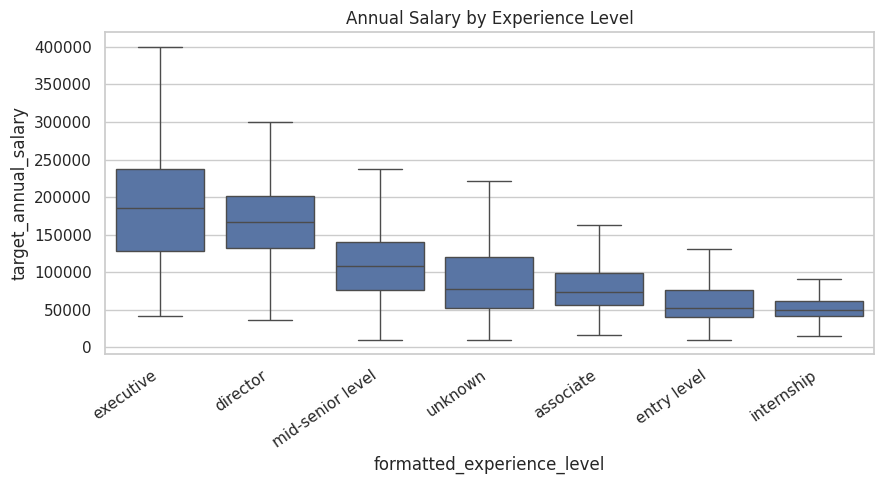

In [27]:
if exp_col in train.columns:
    order = grp.index.tolist()
    plt.figure(figsize=(9, 5))
    sns.boxplot(data=train, x=exp_col, y="target_annual_salary", order=order, showfliers=False)
    plt.xticks(rotation=35, ha="right")
    plt.title("Annual Salary by Experience Level")
    plt.tight_layout()
    plt.show()

**Interpretation guidance:** If median salary increases roughly
monotonically across a semantically sensible ordering (Internship ->
Entry -> Associate -> Mid-Senior -> Director -> Executive), an ordinal
encoding is *defensible* to try as an experiment later — but for the
first Ridge baseline, **OneHotEncoder is the safer default**: it makes
no assumption about equal spacing between levels and lets the
regularized linear model learn level-specific effects directly.

---
## Section 11 — Work Type Analysis

**What:** Category counts/percentages and salary cuts for
`formatted_work_type`, with a rare-category flag.

**Why:** Determines whether Full-time/Part-time/Contract/etc. have
enough support to be trusted category-level salary signals, and whether
`OneHotEncoder(handle_unknown="ignore")` is safe.

**Effect on future model:** `formatted_work_type` is classified as an
OPTIONAL categorical feature in the proposed core set (Section 26) —
this section checks whether that classification is justified.

In [28]:
wt_col = "formatted_work_type"
if wt_col in train.columns:
    vc = train[wt_col].value_counts(dropna=True)
    rows = []
    for cat, cnt in vc.items():
        sal = train.loc[train[wt_col] == cat, "target_annual_salary"]
        rows.append({
            "category": cat, "count": cnt,
            "percentage": round(100*cnt/len(train), 2),
            "median_salary": sal.median(), "mean_salary": sal.mean(),
        })
    wt_report = pd.DataFrame(rows).sort_values("count", ascending=False)
    display(wt_report.round(0))

    RARE_THRESHOLD_PCT = 1.0
    rare = wt_report[wt_report["percentage"] < RARE_THRESHOLD_PCT]
    if len(rare):
        print(f"\nCategories below {RARE_THRESHOLD_PCT}% of rows (low support):")
        display(rare)
    else:
        print(f"\nNo categories below {RARE_THRESHOLD_PCT}% of rows.")

    print("\nRecommendation: OneHotEncoder(handle_unknown='ignore') is suitable"
          " given the bounded, low-cardinality category set.")
else:
    print("formatted_work_type not present.")

,category,count,percentage,median_salary,mean_salary
0,full-time,27654,82.0,85000.0,99214.0
1,contract,3475,10.0,95727.0,101611.0
2,part-time,1923,6.0,42000.0,58890.0
3,temporary,327,1.0,56160.0,74819.0
4,internship,211,1.0,44720.0,54767.0
5,other,116,0.0,65500.0,85212.0
6,volunteer,2,0.0,50000.0,50000.0



Categories below 1.0% of rows (low support):


,category,count,percentage,median_salary,mean_salary
3,temporary,327,0.97,56160.0,74818.730489
4,internship,211,0.63,44720.0,54766.750711
5,other,116,0.34,65500.0,85211.833621
6,volunteer,2,0.01,50000.0,50000.000000



Recommendation: OneHotEncoder(handle_unknown='ignore') is suitable given the bounded, low-cardinality category set.


**Interpretation guidance:** Work type is typically low-cardinality
(Full-time/Part-time/Contract/Temporary/Internship/Other), so cardinality
risk is minimal. The main watch item is whether any single category is
so rare it can't support a stable coefficient — `handle_unknown="ignore"`
protects inference-time robustness regardless.

---
## Section 12 — Location Feature Analysis

**What:** Country/state coverage and salary variation, plus a check of
whether raw `location` metadata is redundant with `company_state` /
`company_country` and too high-cardinality to use directly.

**Why:** Location is highly predictive of salary (cost-of-living,
regional demand) *and* realistically knowable by a user — but only in a
coarse form (state/country), not as an exact LinkedIn location string.

**Effect on future model:** Chooses between raw `location` and
structured `company_state` / `company_country` for the core feature set,
and confirms the product should ask for State + Country, not free text.

In [29]:
country_col, state_col, loc_col = "company_country", "company_state", "location"
present = [c for c in [country_col, state_col, loc_col] if c in train.columns]

if country_col in train.columns:
    n_countries = train[country_col].nunique(dropna=True)
    us_share = None
    top_country = train[country_col].value_counts(dropna=True)
    print(f"Distinct countries: {n_countries}")
    display(top_country.head(10).to_frame("count"))
    if len(top_country):
        us_share = 100 * top_country.iloc[0] / top_country.sum()
        print(f"\nTop country '{top_country.index[0]}' share: {us_share:.2f}% of non-null rows")

Distinct countries: 44


,count
company_country,
us,30698
gb,1097
0,618
ca,306
ch,144
de,114
fr,112
se,86
in,73



Top country 'us' share: 91.07% of non-null rows


In [30]:
if state_col in train.columns:
    n_states = train[state_col].nunique(dropna=True)
    print(f"Distinct states: {n_states}")
    state_grp = train.groupby(state_col)["target_annual_salary"].agg(count="count", median="median", mean="mean")
    well_supported = state_grp[state_grp["count"] >= 50].sort_values("median", ascending=False)
    print(f"\nStates with >= 50 observations: {len(well_supported)} of {n_states}")
    display(well_supported.round(0))

Distinct states: 340

States with >= 50 observations: 72 of 340


,count,median,mean
company_state,,,
london,94,125000.0,147779.0
weybridge,63,117500.0,126240.0
wa,614,109995.0,114629.0
indiana,155,106000.0,133778.0
england,398,105625.0,118168.0
...,...,...,...
minnesota,169,58240.0,74746.0
ky,77,57400.0,62194.0
arkansas,70,54080.0,80477.0


In [31]:
if loc_col in train.columns:
    n_loc = train[loc_col].nunique(dropna=True)
    print(f"Distinct raw location strings : {n_loc:,}")
    if state_col in train.columns:
        n_state = train[state_col].nunique(dropna=True)
        print(f"Distinct company_state values : {n_state:,}")
        print(f"Location cardinality is {n_loc / max(n_state,1):.1f}x higher than company_state")
    print("\nraw 'location' is treated as METADATA -- too high-cardinality for direct")
    print("one-hot encoding, and its useful signal is already summarized by state/country.")

Distinct raw location strings : 4,365
Distinct company_state values : 340
Location cardinality is 12.8x higher than company_state

raw 'location' is treated as METADATA -- too high-cardinality for direct
one-hot encoding, and its useful signal is already summarized by state/country.


**Interpretation guidance:** Expect the dataset to skew heavily toward
one country (commonly the US on LinkedIn postings data) — if so,
`company_country` will have low variance and most of the *useful*
location signal will live in `company_state`. **Product design
implication:** ask users for **State + Country** via a dropdown, never a
free-text LinkedIn-style location string — this matches both the
model's structured input and realistic user knowledge.

---
## Section 13 — Industry Analysis

**What:** Missingness, cardinality, category frequencies, and
well-supported industries ranked by salary for `top_industry`.

**Why:** Industry is a strong, realistic user input (most people know
what industry they work in) with likely nonlinear/interaction effects
with title and experience.

**Effect on future model:** Confirms `top_industry` as a CORE categorical
feature, and whether rare-industry grouping is needed.

In [32]:
ind_col = "top_industry"
if ind_col in train.columns:
    print(f"missing_pct : {100*train[ind_col].isna().mean():.2f}%")
    print(f"nunique     : {train[ind_col].nunique(dropna=True):,}")

    vc = train[ind_col].value_counts(dropna=True)
    MIN_SUPPORT = 50
    well_supported = vc[vc >= MIN_SUPPORT]
    print(f"Industries with >= {MIN_SUPPORT} postings: {len(well_supported)} of {len(vc)}")

    rows = []
    for cat, cnt in well_supported.items():
        sal = train.loc[train[ind_col] == cat, "target_annual_salary"]
        rows.append({"industry": cat, "count": cnt, "median_salary": sal.median(), "mean_salary": sal.mean()})
    ind_report = pd.DataFrame(rows).sort_values("median_salary", ascending=False)

    print("\nTop-paying well-supported industries:")
    display(ind_report.head(15).round(0))
    print("\nLowest-paying well-supported industries:")
    display(ind_report.tail(10).round(0))

    rare_rows_pct = 100 * vc[vc < MIN_SUPPORT].sum() / len(train)
    print(f"\nRows belonging to industries with < {MIN_SUPPORT} postings: {rare_rows_pct:.2f}% of training data")
else:
    print("top_industry not present.")

missing_pct : 0.07%
nunique     : 332
Industries with >= 50 postings: 88 of 332

Top-paying well-supported industries:


,industry,count,median_salary,mean_salary
80,capital markets,61,180000.0,281014.0
26,information services,315,146852.0,150517.0
44,computer and network security,195,139500.0,146984.0
45,computer hardware manufacturing,180,133973.0,133781.0
65,semiconductor manufacturing,91,132500.0,127696.0
5,software development,1113,130500.0,132888.0
30,defense and space manufacturing,247,126800.0,128897.0
24,"technology, information and internet",336,126190.0,137560.0
74,computers and electronics manufacturing,74,125925.0,135979.0
79,internet marketplace platforms,61,120640.0,118457.0



Lowest-paying well-supported industries:


,industry,count,median_salary,mean_salary
27,"transportation, logistics, supply chain and st...",270,55060.0,65403.0
53,individual and family services,136,53761.0,61995.0
48,facilities services,157,52500.0,64055.0
56,veterinary services,124,51220.0,78606.0
13,hospitality,527,50544.0,65078.0
67,wholesale,86,50000.0,60682.0
40,restaurants,207,45240.0,60468.0
54,security and investigations,135,45000.0,57420.0
4,retail,1431,40102.0,52291.0
61,freight and package transportation,104,38636.0,49304.0



Rows belonging to industries with < 50 postings: 6.33% of training data


**Interpretation guidance:** Industries with tiny sample sizes are
**excluded from the ranked tables above** by construction — do not read
significance into any industry missing from the well-supported list.
If rare-industry rows are a small share of the dataset,
`OneHotEncoder(handle_unknown="ignore")` alone is fine; if they're
sizable, grouping rare industries into an "Other" bucket before encoding
is a reasonable experiment.

---
## Section 14 — Company Size Analysis

**What:** Determine `company_size`'s actual representation (continuous,
bucketed, ordinal code, or string) and its relationship with salary.

**Why:** A numeric-looking `company_size` might actually be a LinkedIn
size **bucket code** (e.g., 1-9), not a literal employee count — treating
it as continuous without checking would be a silent modeling error.

**Effect on future model:** Chooses one-hot vs. ordinal vs. numeric vs.
exclude for `company_size`.

In [33]:
size_col = "company_size"
if size_col in train.columns:
    print(f"dtype: {train[size_col].dtype}")
    vc = train[size_col].value_counts(dropna=True).sort_index()
    print(f"nunique: {train[size_col].nunique(dropna=True)}")
    display(vc.to_frame("count"))

    is_small_int_set = pd.api.types.is_numeric_dtype(train[size_col]) and vc.index.size <= 15
    print(f"\nLooks like a small bucket/code set (<=15 distinct numeric values): {is_small_int_set}")
else:
    print("company_size not present.")

dtype: category
nunique: 8


,count
company_size,
1.0,2952
2.0,4105
3.0,2862
4.0,2687
5.0,6418
6.0,2837
7.0,10200
unknown,1647



Looks like a small bucket/code set (<=15 distinct numeric values): False


,count,median,mean
company_size,,,
1.0,2952,87500.0,100885.0
2.0,4105,90000.0,101979.0
3.0,2862,91995.0,104205.0
4.0,2687,82500.0,95930.0
5.0,6418,82500.0,96027.0
6.0,2837,75000.0,89460.0
7.0,10200,74535.0,91279.0
unknown,1647,92500.0,110772.0


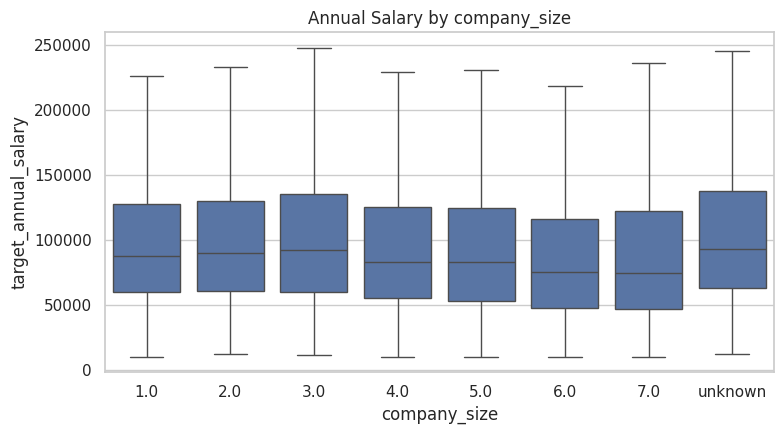

In [34]:
if size_col in train.columns:
    size_grp = train.groupby(size_col)["target_annual_salary"].agg(count="count", median="median", mean="mean")
    display(size_grp.sort_index().round(0))

    plt.figure(figsize=(8, 4.5))
    order = size_grp.sort_index().index.astype(str).tolist()
    sns.boxplot(data=train.assign(**{size_col: train[size_col].astype(str)}),
                x=size_col, y="target_annual_salary", order=order, showfliers=False)
    plt.title("Annual Salary by company_size")
    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

**Interpretation guidance:** If `company_size` takes a small number of
distinct integer values with a roughly monotonic salary relationship, it
is very likely a **LinkedIn size bucket code**, not a literal headcount —
in that case treat it as **categorical/ordinal via OneHotEncoder**, not
as a raw numeric feature. Only treat it as continuous numeric if the
values genuinely look like raw headcounts (wide range, high cardinality)
after visual inspection above.

---
## Section 15 — Raw vs. Log Company Employee Count

**What:** Compare `company_employee_count` and
`log_company_employee_count`: missingness, distribution stats,
skewness, distributions, and correlation between the two.

**Why:** A regularized linear model doesn't need two forms of the same
information — carrying both raw and log versions typically just adds
redundant, correlated columns without new signal.

**Effect on future model:** Chooses whether to keep both, keep only the
log version, or drop both — and separately classifies product-input
realism (would a user *know* exact employee count?).

In [35]:
raw_col, log_col = "company_employee_count", "log_company_employee_count"
present_cols = [c for c in [raw_col, log_col] if c in train.columns]

def numeric_report(col):
    s = train[col]
    return pd.Series({
        "missing_pct": round(100*s.isna().mean(), 2),
        "min": s.min(), "median": s.median(), "mean": s.mean(),
        "P95": s.quantile(0.95), "P99": s.quantile(0.99), "max": s.max(),
        "skewness": stats.skew(s.dropna()),
    })

if present_cols:
    display(pd.DataFrame({c: numeric_report(c) for c in present_cols}).round(3))

,company_employee_count,log_company_employee_count
missing_pct,0.000,0.000
min,0.000,0.000
median,1405.000,7.249
mean,17105.391,7.076
P95,74847.000,11.223
P99,285785.000,12.563
max,810296.000,13.605
skewness,8.448,-0.194


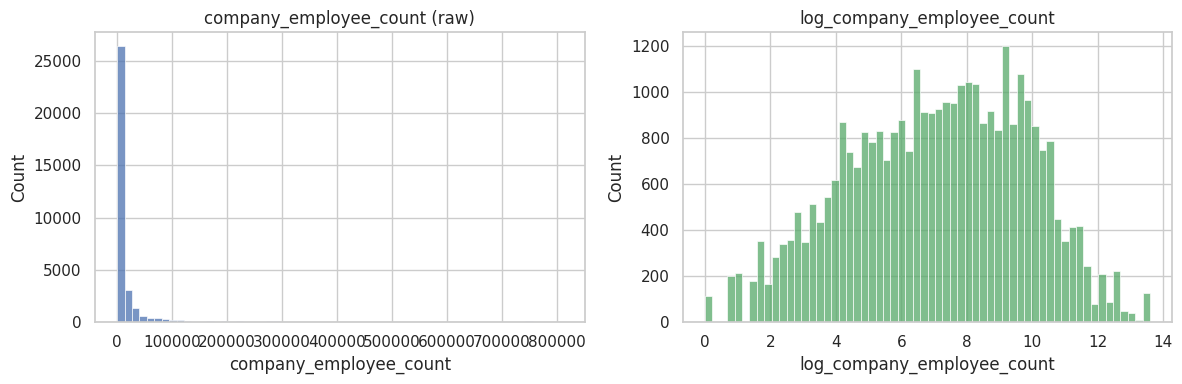

Pearson correlation (raw vs. log): 0.4562

Decision candidate: DROP raw company_employee_count, KEEP log_company_employee_count
(raw is heavily right-skewed; the log transform already exists upstream and the two
 columns are, by construction, near-perfectly related -- carrying both is redundant
 for a regularized linear model.)


In [36]:
if raw_col in train.columns and log_col in train.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(train[raw_col].dropna(), bins=60, ax=axes[0], color="#4C72B0")
    axes[0].set_title("company_employee_count (raw)")
    sns.histplot(train[log_col].dropna(), bins=60, ax=axes[1], color="#55A868")
    axes[1].set_title("log_company_employee_count")
    plt.tight_layout()
    plt.show()

    both = train[[raw_col, log_col]].dropna()
    corr = both[raw_col].corr(both[log_col])
    print(f"Pearson correlation (raw vs. log): {corr:.4f}")
    print("\nDecision candidate: DROP raw company_employee_count, KEEP log_company_employee_count")
    print("(raw is heavily right-skewed; the log transform already exists upstream and the two")
    print(" columns are, by construction, near-perfectly related -- carrying both is redundant")
    print(" for a regularized linear model.)")

**Product usability:** A normal user does **not** know a company's exact
employee count. Classification: **OPTIONAL / AUTOMATICALLY LOOKED-UP**
— if used at all, this should come from a backend company lookup keyed
off company name, never a required manual field. It is *not part of the
minimum user-input contract*.

---
## Section 16 — Raw vs. Log Company Follower Count

**What:** Same statistical treatment as Section 15, applied to
`company_follower_count` / `log_company_follower_count`.

**Why:** Even if follower count predicts salary (larger, more
established/famous companies may pay more), it is not something a salary
estimation product should ask a user for.

**Effect on future model:** Separately reports predictive usefulness
(statistical) vs. product usefulness (design) — these can and often do
disagree.

In [37]:
raw_col, log_col = "company_follower_count", "log_company_follower_count"
present_cols = [c for c in [raw_col, log_col] if c in train.columns]
if present_cols:
    display(pd.DataFrame({c: numeric_report(c) for c in present_cols}).round(3))

,company_follower_count,log_company_follower_count
missing_pct,0.000000e+00,0.000
min,0.000000e+00,0.000
median,6.144300e+04,11.026
mean,7.227911e+05,10.884
P95,2.542987e+06,14.749
P99,1.546771e+07,16.554
max,3.270284e+07,17.303
skewness,8.172000e+00,-0.424


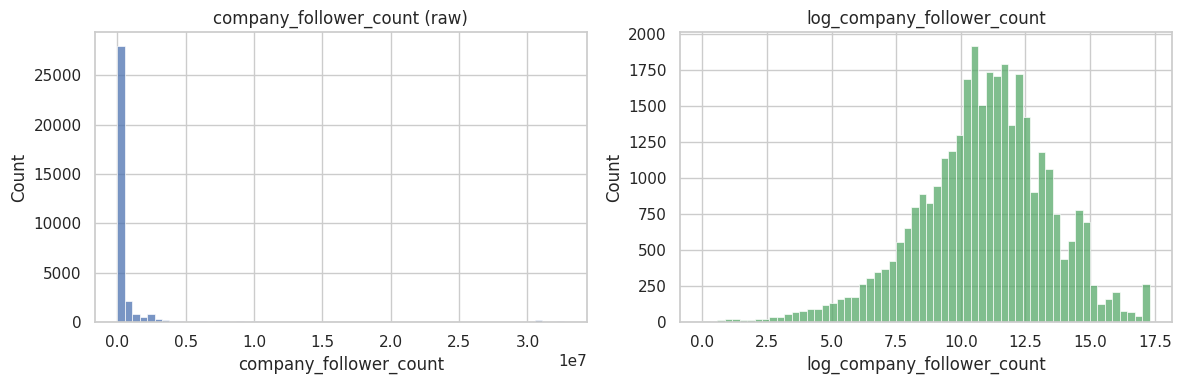

Pearson correlation (raw vs. log)                : 0.4320
Pearson correlation (log_follower vs. log_salary): 0.1582


In [38]:
if raw_col in train.columns and log_col in train.columns:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(train[raw_col].dropna(), bins=60, ax=axes[0], color="#4C72B0")
    axes[0].set_title("company_follower_count (raw)")
    sns.histplot(train[log_col].dropna(), bins=60, ax=axes[1], color="#55A868")
    axes[1].set_title("log_company_follower_count")
    plt.tight_layout()
    plt.show()

    both = train[[raw_col, log_col]].dropna()
    corr = both[raw_col].corr(both[log_col])
    log_target_corr = both[log_col].corr(train.loc[both.index, "target_log_salary"])
    print(f"Pearson correlation (raw vs. log)                : {corr:.4f}")
    print(f"Pearson correlation (log_follower vs. log_salary): {log_target_corr:.4f}")

**Statistical usefulness:** whatever correlation with salary is observed
above is reported at face value — it may be real (bigger/well-known
companies) or confounded with company size/industry.

**Product usefulness:** a user should not be expected to know a
company's LinkedIn follower count. **Classification: EXPERIMENTAL /
optional model feature only — excluded from the minimum user-input
contract regardless of statistical performance.** This will be tested in
Ablation E6 (Section 28) to see if it adds validation-set lift over the
core feature set.

---
## Section 17 — skill_count Analysis

**What:** Distribution of `skill_count`, its relationship with salary
across bins, and redundancy against `skill_list`.

**Why:** `skill_count` is very likely a **derived** feature (count of
items in `skill_list`) rather than something a user would type in
directly.

**Effect on future model:** Classifies `skill_count` as an
automatically-derived numeric feature, not a form field.

In [39]:
sc_col = "skill_count"
if sc_col in train.columns:
    s = train[sc_col]
    print(f"missing_pct : {100*s.isna().mean():.2f}%")
    display(s.describe(percentiles=[0.5, 0.95, 0.99]).round(2))

    bins = [-0.1, 0, 2, 5, 10, 20, np.inf]
    labels = ["0", "1-2", "3-5", "6-10", "11-20", "20+"]
    binned = pd.cut(s, bins=bins, labels=labels)
    bin_grp = train.groupby(binned)["target_annual_salary"].agg(count="count", median="median")
    display(bin_grp)

    if has_skill_list and parse_reliable:
        compare_df = pd.DataFrame({
            "derived": skills_per_posting.reindex(s.index),
            "actual": s,
        }).dropna()
        agree = (compare_df["derived"] == compare_df["actual"]).mean()
        print(f"\nAgreement between skill_count and len(parsed skill_list): {100*agree:.1f}%")
        print("High agreement supports treating skill_count as a DERIVED feature (not a form field).")
else:
    print("skill_count not present.")

missing_pct : 0.00%


,skill_count
count,33708.00
mean,1.70
std,0.73
min,0.00
50%,2.00
95%,3.00
99%,3.00
max,3.00


,count,median
skill_count,,
0,471,68500.0
1-2,28181,81120.0
3-5,5056,89440.0
6-10,0,NaN
11-20,0,NaN
20+,0,NaN



Agreement between skill_count and len(parsed skill_list): 100.0%
High agreement supports treating skill_count as a DERIVED feature (not a form field).


**Interpretation guidance:** Even a mild positive relationship between
`skill_count` and salary is plausible (more listed skills -> more senior
or more technical roles), but this should be **computed automatically
from the user's entered skills** at inference time rather than asked as
its own form field — classified as **DERIVED**.

---
## Section 18 — Numeric Feature Correlation / Redundancy

**What:** Pearson and Spearman correlations among numeric candidates
(and with the target, for exploratory purposes only), visualized as a
heatmap.

**Why:** Identifies redundant predictor pairs (e.g., raw vs. log
versions) and gives a rough, **non-decisive** read on linear
relationships with salary.

**Effect on future model:** Correlation informs — but does not solely
determine — which numeric features are dropped as redundant in
Section 25/26.

In [40]:
numeric_present = [c for c in NUMERIC_CANDIDATES if c in train.columns]
corr_cols = numeric_present + ["target_annual_salary", "target_log_salary"]
corr_df = train[corr_cols].dropna()

pearson_corr = corr_df.corr(method="pearson")
spearman_corr = corr_df.corr(method="spearman")

print("Pearson correlation:")
display(pearson_corr.round(3))
print("\nSpearman correlation:")
display(spearman_corr.round(3))

Pearson correlation:


,company_employee_count,company_follower_count,skill_count,log_company_employee_count,log_company_follower_count,target_annual_salary,target_log_salary
company_employee_count,1.000,0.830,0.098,0.456,0.428,0.094,0.098
company_follower_count,0.830,1.000,0.109,0.364,0.432,0.154,0.156
skill_count,0.098,0.109,1.000,0.034,0.077,0.026,0.027
log_company_employee_count,0.456,0.364,0.034,1.000,0.788,-0.021,-0.038
log_company_follower_count,0.428,0.432,0.077,0.788,1.000,0.147,0.158
target_annual_salary,0.094,0.154,0.026,-0.021,0.147,1.000,0.913
target_log_salary,0.098,0.156,0.027,-0.038,0.158,0.913,1.000



Spearman correlation:


,company_employee_count,company_follower_count,skill_count,log_company_employee_count,log_company_follower_count,target_annual_salary,target_log_salary
company_employee_count,1.000,0.767,0.031,1.000,0.767,-0.046,-0.046
company_follower_count,0.767,1.000,0.054,0.767,1.000,0.152,0.152
skill_count,0.031,0.054,1.000,0.031,0.054,0.015,0.015
log_company_employee_count,1.000,0.767,0.031,1.000,0.767,-0.046,-0.046
log_company_follower_count,0.767,1.000,0.054,0.767,1.000,0.152,0.152
target_annual_salary,-0.046,0.152,0.015,-0.046,0.152,1.000,1.000
target_log_salary,-0.046,0.152,0.015,-0.046,0.152,1.000,1.000


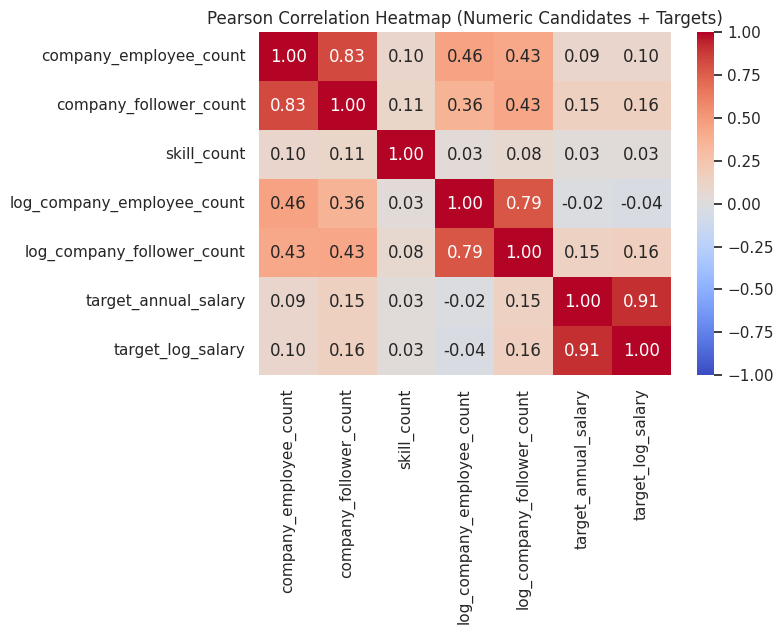

In [41]:
fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(pearson_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax, vmin=-1, vmax=1)
ax.set_title("Pearson Correlation Heatmap (Numeric Candidates + Targets)")
plt.tight_layout()
plt.show()

In [42]:
pairs_of_interest = [
    ("company_employee_count", "log_company_employee_count"),
    ("company_follower_count", "log_company_follower_count"),
    ("skill_count", "target_annual_salary"),
]
for a, b in pairs_of_interest:
    if a in pearson_corr.index and b in pearson_corr.columns:
        print(f"{a} vs {b}: Pearson r = {pearson_corr.loc[a, b]:.3f}, Spearman rho = {spearman_corr.loc[a, b]:.3f}")

company_employee_count vs log_company_employee_count: Pearson r = 0.456, Spearman rho = 1.000
company_follower_count vs log_company_follower_count: Pearson r = 0.432, Spearman rho = 1.000
skill_count vs target_annual_salary: Pearson r = 0.026, Spearman rho = 0.015


**Interpretation guidance:** Very high |r| between a raw/log pair
confirms redundancy already suspected in Sections 15–16 — that's the
strongest, least ambiguous use of correlation here. Correlation between
any single numeric feature and the target is expected to be modest even
for genuinely useful features, since most of the signal in this dataset
lives in text and categorical fields; **do not drop a feature for low
target correlation alone** (Safety Rule #13).

---
## Section 19 — Metadata / Leakage / Non-Predictor Audit

**What:** Explicit review of columns kept in the dataset for reasons
*other* than direct prediction — company identity, raw location, time
stamps, and provenance/target-construction metadata.

**Why:** Some of these are borderline-useful-but-risky
(`company_name`), some are only useful in coarser form (`location`), and
some must never be predictors under any circumstances
(`posting_group_id`, `dataset_version`, `salary_target_source`).

**Effect on future model:** Produces the exclusion list enforced in
Section 20's leakage check.

In [43]:
metadata_present = [c for c in METADATA if c in train.columns]

reasoning = {
    "company_name": "Potentially predictive but very high cardinality; encourages memorization "
                     "of specific companies rather than generalizable salary drivers. Excluded from first model.",
    "location": "Raw LinkedIn location string is high-cardinality and largely redundant with "
                "company_state/company_country, which are safer, coarser, and more product-realistic.",
    "original_listed_time": "Timestamp of original listing; no clear inference-time meaning for a "
                             "user requesting a salary estimate 'now'. Not included automatically.",
    "listed_time": "Same reasoning as original_listed_time -- posting timestamp, not a job characteristic.",
    "dataset_version": "Data provenance / pipeline versioning artifact, not a real-world job characteristic.",
    "posting_group_id": "Used exclusively for leakage-safe GroupShuffleSplit; has no predictive meaning "
                         "and must never enter the feature matrix.",
    "salary_target_source": "Describes how the target was constructed (target-construction metadata); "
                             "using it as a predictor would leak target-construction information.",
}

rows = []
for c in metadata_present:
    rows.append({
        "feature": c,
        "reason_retained_in_dataset": "kept for traceability/product context, not modeling" if c in
            ("company_name", "location") else "pipeline/provenance support",
        "should_be_predictor": False,
        "reason": reasoning.get(c, "Metadata column; not evaluated as a direct predictor in this audit."),
    })

metadata_decision = pd.DataFrame(rows)
metadata_decision

,feature,reason_retained_in_dataset,should_be_predictor,reason
0,company_name,"kept for traceability/product context, not mod...",False,Potentially predictive but very high cardinali...
1,location,"kept for traceability/product context, not mod...",False,Raw LinkedIn location string is high-cardinali...
2,original_listed_time,pipeline/provenance support,False,Timestamp of original listing; no clear infere...
3,listed_time,pipeline/provenance support,False,Same reasoning as original_listed_time -- post...
4,dataset_version,pipeline/provenance support,False,Data provenance / pipeline versioning artifact...
5,posting_group_id,pipeline/provenance support,False,Used exclusively for leakage-safe GroupShuffle...
6,salary_target_source,pipeline/provenance support,False,Describes how the target was constructed (targ...


**Interpretation guidance:** Every row in this table is
`should_be_predictor = False` by design for the first generalizable
model. `company_name` and `location` are the two with genuine long-run
potential (e.g., company-level fixed effects, or location if aggregated
more coarsely), but both are intentionally deferred to a later,
carefully regularized experiment rather than included in the baseline
feature set.

---
## Section 20 — Target Leakage Safety Audit

**What:** Explicitly verify that no salary-derived or post-outcome
column is present in the proposed predictor list.

**Why:** This is the single most important correctness check in the
notebook — any leakage column entering `X` would make offline metrics
look artificially good while being useless (or actively broken) at real
inference time, when none of this information exists yet.

**Effect on future model:** Hard gate before any preprocessing blueprint
is finalized.

In [44]:
LEAKAGE_COLUMNS = [
    "target_annual_salary", "target_log_salary",
    "min_salary", "med_salary", "max_salary", "normalized_salary",
    "listed_min_salary", "listed_med_salary", "listed_max_salary",
    "salary_available", "pay_period", "currency", "listed_currency",
    "listed_pay_period", "listed_compensation_type",
    "views", "applies", "closed_time", "expiry",
]

proposed_predictors = set(TEXT_CANDIDATES + CATEGORICAL_CANDIDATES + NUMERIC_CANDIDATES)
found_leakage = [c for c in LEAKAGE_COLUMNS if c in proposed_predictors]

present_but_excluded = [c for c in LEAKAGE_COLUMNS if c in train.columns]

print("Leakage-risk columns present in train.parquet (excluded from predictors by design):")
for c in present_but_excluded:
    print(f"  - {c}")
if not present_but_excluded:
    print("  (none of the listed leakage-risk columns exist in this dataset)")

print()
if found_leakage:
    print("*** WARNING: LEAKAGE COLUMNS FOUND IN PROPOSED PREDICTOR LIST ***")
    for c in found_leakage:
        print(f"  !! {c}")
else:
    print("LEAKAGE CHECK: PASS -- no leakage/outcome columns present in the proposed predictor list.")

Leakage-risk columns present in train.parquet (excluded from predictors by design):
  - target_annual_salary
  - target_log_salary

LEAKAGE CHECK: PASS -- no leakage/outcome columns present in the proposed predictor list.


**Why these are excluded — in plain terms:** every column above only
exists *after* a job posting is published (min/med/max/listed salary
fields, currency/pay period, or post-publication engagement like
`views`/`applies`/`closed_time`/`expiry`). A real user asking "what
salary should I expect for this job" has none of this information
available — including it would let the model implicitly see the answer
(or a close proxy of it) rather than learn to predict it from job
characteristics alone.

---
## Section 21 — Product Input Availability Audit

**What:** Classify every potential model feature by real-world user
availability: REQUIRED, OPTIONAL, AUTOMATICALLY DERIVED,
OPTIONAL BACKEND/LOOKUP, or INTERNAL ONLY.

**Why:** A feature can be statistically useful and still be the wrong
choice for a product's mandatory input form if ordinary users don't
know/have that information.

**Effect on future model:** Produces the bridge table between the ML
audit and the V1 product input contract (Section 27).

In [45]:
product_availability = {
    "title": ("BOTH", "REQUIRED", "user always knows the job title they want an estimate for"),
    "formatted_experience_level": ("BOTH", "REQUIRED", "user knows their own seniority level"),
    "skill_list": ("BOTH", "REQUIRED", "user can list their own skills"),
    "skill_count": ("MODEL-USEFUL", "AUTOMATICALLY DERIVED", "computed from entered skills, not asked directly"),
    "company_state": ("BOTH", "REQUIRED", "user knows the state they work/want to work in"),
    "company_country": ("BOTH", "REQUIRED", "user knows the country"),
    "top_industry": ("BOTH", "REQUIRED (recommended)", "most users know their industry"),
    "formatted_work_type": ("BOTH", "OPTIONAL", "helpful but not essential; defaults reasonably to Full-time"),
    "company_size": ("BOTH", "OPTIONAL", "many users have a rough idea (startup/mid/large) but not exact bucket"),
    "company_employee_count": ("MODEL-USEFUL (redundant w/ log)", "OPTIONAL / BACKEND LOOKUP", "exact headcount unrealistic as manual input"),
    "log_company_employee_count": ("MODEL-USEFUL", "OPTIONAL / BACKEND LOOKUP", "derived from a backend company lookup, not user-entered"),
    "company_follower_count": ("EXPERIMENTAL", "NOT MINIMUM INPUT", "users don't know a company's LinkedIn follower count"),
    "log_company_follower_count": ("EXPERIMENTAL", "NOT MINIMUM INPUT", "same reasoning, log-transformed"),
    "top_skill": ("EXPERIMENTAL / LIKELY REDUNDANT", "AUTOMATICALLY DERIVED", "derive as the most common entered skill if kept at all"),
    "company_name": ("NEITHER (excluded from model)", "OPTIONAL (product context only)", "not used as a predictor in V1"),
    "location": ("NEITHER (excluded from model)", "NOT USED", "superseded by state/country"),
    "posting_group_id": ("NEITHER", "INTERNAL ONLY", "leakage-safe split key, never a predictor or input"),
    "dataset_version": ("NEITHER", "INTERNAL ONLY", "pipeline provenance"),
    "salary_target_source": ("NEITHER", "INTERNAL ONLY", "target-construction metadata"),
}

rows = []
for feat, (model_role, avail, why) in product_availability.items():
    rows.append({
        "feature": feat,
        "model_role": model_role,
        "user_availability": avail,
        "can_be_derived": "derive" in why.lower() or "computed" in why.lower(),
        "reasoning": why,
    })

product_table = pd.DataFrame(rows)
product_table

,feature,model_role,user_availability,can_be_derived,reasoning
0,title,BOTH,REQUIRED,False,user always knows the job title they want an e...
1,formatted_experience_level,BOTH,REQUIRED,False,user knows their own seniority level
2,skill_list,BOTH,REQUIRED,False,user can list their own skills
3,skill_count,MODEL-USEFUL,AUTOMATICALLY DERIVED,True,"computed from entered skills, not asked directly"
4,company_state,BOTH,REQUIRED,False,user knows the state they work/want to work in
5,company_country,BOTH,REQUIRED,False,user knows the country
6,top_industry,BOTH,REQUIRED (recommended),False,most users know their industry
7,formatted_work_type,BOTH,OPTIONAL,False,helpful but not essential; defaults reasonably...
8,company_size,BOTH,OPTIONAL,False,many users have a rough idea (startup/mid/larg...
9,company_employee_count,MODEL-USEFUL (redundant w/ log),OPTIONAL / BACKEND LOOKUP,False,exact headcount unrealistic as manual input


**Interpretation guidance:** The `MODEL-USEFUL` / `PRODUCT-USEFUL` /
`BOTH` / `NEITHER` framing (requested in the project brief) collapses to:
features in the `BOTH` bucket are the backbone of the V1 form;
`MODEL-USEFUL`-only features (follower/employee count) are backend
lookups or experimental extras, never mandatory fields; `NEITHER`
features are internal/metadata and never surfaced to the model or the
user.

---
## Section 22 — Missing Input Simulation / Product Robustness

**What:** For increasingly strict combinations of required fields,
compute how many training rows have *all* of those fields populated.

**Why:** A feature can be predictive but a poor mandatory input if
requiring it eliminates a large share of usable rows/postings — that's a
product coverage problem, not just a modeling one.

**Effect on future model:** Directly shapes the "required vs.
recommended vs. optional" boundary in Section 27. No rows are dropped
here — this is read-only simulation.

In [46]:
def coverage(cols):
    cols = [c for c in cols if c in train.columns]
    mask = train[cols].notna().all(axis=1) if cols else pd.Series(True, index=train.index)
    return mask, cols

scenarios = {
    "A: title only": ["title"],
    "B: title + experience": ["title", "formatted_experience_level"],
    "C: title + experience + state/country": ["title", "formatted_experience_level", "company_state", "company_country"],
    "D: C + industry": ["title", "formatted_experience_level", "company_state", "company_country", "top_industry"],
    "E: D + skills": ["title", "formatted_experience_level", "company_state", "company_country", "top_industry", "skill_list"],
    "F: all candidate features": TEXT_CANDIDATES + CATEGORICAL_CANDIDATES + NUMERIC_CANDIDATES,
}

rows = []
for name, cols in scenarios.items():
    mask, used_cols = coverage(cols)
    rows.append({
        "scenario": name,
        "fields_used": ", ".join(used_cols),
        "rows_with_all_fields": int(mask.sum()),
        "coverage_pct": round(100 * mask.mean(), 2),
    })

coverage_table = pd.DataFrame(rows)
coverage_table

,scenario,fields_used,rows_with_all_fields,coverage_pct
0,A: title only,title,33708,100.00
1,B: title + experience,"title, formatted_experience_level",33708,100.00
2,C: title + experience + state/country,"title, formatted_experience_level, company_sta...",33708,100.00
3,D: C + industry,"title, formatted_experience_level, company_sta...",33686,99.93
4,E: D + skills,"title, formatted_experience_level, company_sta...",33220,98.55
5,F: all candidate features,"title, skill_list, formatted_experience_level,...",33220,98.55


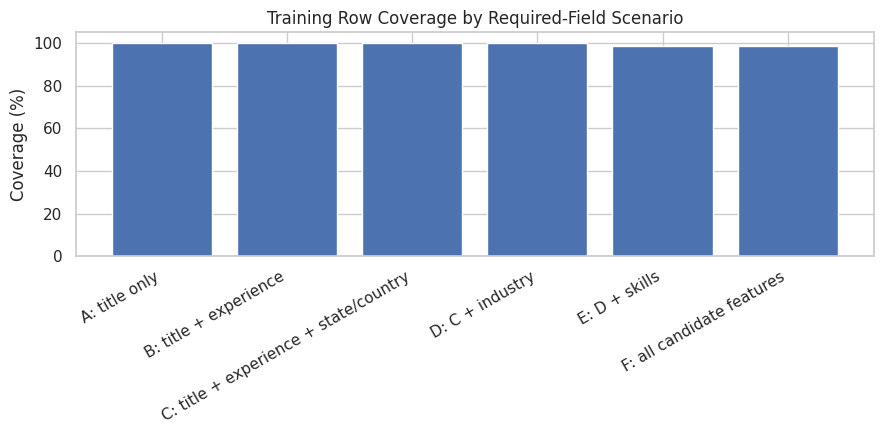

In [47]:
plt.figure(figsize=(9, 4.5))
plt.bar(coverage_table["scenario"], coverage_table["coverage_pct"], color="#4C72B0")
plt.ylabel("Coverage (%)")
plt.title("Training Row Coverage by Required-Field Scenario")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**Interpretation guidance:** A steep coverage drop between two adjacent
scenarios flags the field that just became mandatory as the
missingness bottleneck. If Scenario E (adding skills) drops coverage
sharply relative to D, that's evidence `skill_list` should be
**recommended, not strictly required** — the model/product should
degrade gracefully (impute/omit) rather than block estimation entirely.

---
## Section 23 — Feature Coverage vs. Salary Representativeness

**What:** Compare row count, median salary, and salary distribution for
each required-field scenario against the full training dataset.

**Why:** If requiring a field disproportionately keeps only a specific
subpopulation (e.g., mostly tech jobs), making it mandatory introduces
selection bias into both the offline evaluation and the live product.

**Effect on future model:** A red flag here argues for making that field
optional even if Section 22 coverage looked acceptable.

In [48]:
full_median = train["target_annual_salary"].median()
rows = []
for name, cols in scenarios.items():
    mask, _ = coverage(cols)
    subset = train.loc[mask, "target_annual_salary"]
    rows.append({
        "scenario": name,
        "n_rows": len(subset),
        "median_salary": subset.median(),
        "mean_salary": subset.mean(),
        "delta_vs_full_median_pct": round(100 * (subset.median() - full_median) / full_median, 2),
    })

representativeness = pd.DataFrame(rows)
print(f"Full training median salary: {full_median:,.0f}")
representativeness.round(1)

Full training median salary: 82,500


,scenario,n_rows,median_salary,mean_salary,delta_vs_full_median_pct
0,A: title only,33708,82500.0,96594.8,0.0
1,B: title + experience,33708,82500.0,96594.8,0.0
2,C: title + experience + state/country,33708,82500.0,96594.8,0.0
3,D: C + industry,33686,82500.0,96598.9,0.0
4,E: D + skills,33220,82500.0,96888.7,0.0
5,F: all candidate features,33220,82500.0,96888.7,0.0


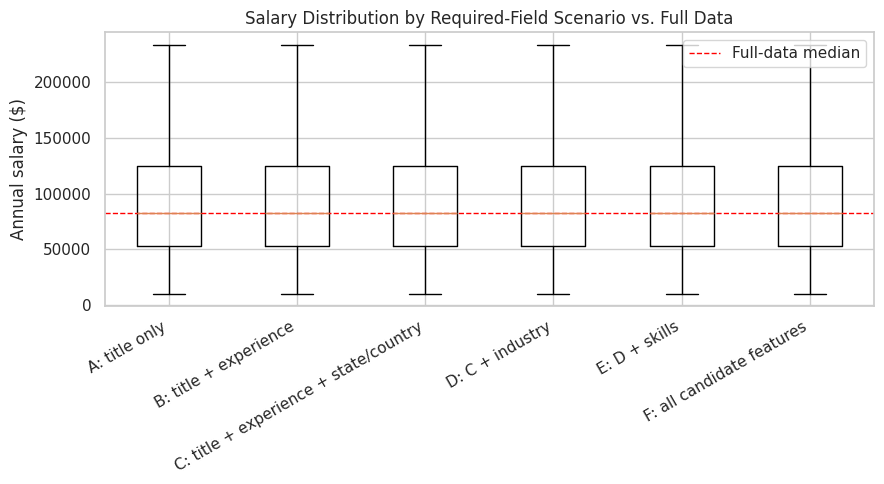

In [49]:
plt.figure(figsize=(9, 5))
subset_names = list(scenarios.keys())
data_for_plot = []
labels_for_plot = []
for name, cols in scenarios.items():
    mask, _ = coverage(cols)
    data_for_plot.append(train.loc[mask, "target_annual_salary"])
    labels_for_plot.append(name)
plt.boxplot(data_for_plot, labels=labels_for_plot, showfliers=False)
plt.axhline(full_median, color="red", linestyle="--", linewidth=1, label="Full-data median")
plt.ylabel("Annual salary ($)")
plt.xticks(rotation=30, ha="right")
plt.legend()
plt.title("Salary Distribution by Required-Field Scenario vs. Full Data")
plt.tight_layout()
plt.show()

**Interpretation guidance:** A `delta_vs_full_median_pct` near zero
means requiring that field combination doesn't obviously bias which
salaries are represented. A large positive or negative delta (e.g.,
skill-list-complete postings skewing toward higher-paying tech roles)
is a genuine selection-bias risk worth flagging in the final report,
even if it doesn't change the recommendation outright.

---
## Section 24 — Cardinality and Sparse Matrix Risk

**What:** Rough dimensionality estimate for the eventual feature matrix:
TF-IDF(title) + TF-IDF/sparse(skills) + one-hot categoricals.

**Why:** Confirms the overall preprocessing design should stay sparse
end-to-end; converting a wide TF-IDF/OHE matrix to a dense array would
blow up memory for no benefit with a linear model.

**Effect on future model:** Sets an explicit engineering constraint for
the Section 29 preprocessing blueprint.

In [50]:
title_vocab_estimate = vocab_size if 'vocab_size' in dir() else None
skill_vocab_estimate = int(all_skills.nunique()) if (has_skill_list and parse_reliable) else None

ohe_dims = 0
for col in CATEGORICAL_PRESENT:
    ohe_dims += train[col].nunique(dropna=True)

print("Approximate dimensionality budget (diagnostic estimate only):")
print(f"  TF-IDF(title)  ~ {title_vocab_estimate if title_vocab_estimate else 'n/a'} columns")
print(f"  skills sparse  ~ {skill_vocab_estimate if skill_vocab_estimate else 'n/a'} columns")
print(f"  one-hot categoricals (sum of nunique across {len(CATEGORICAL_PRESENT)} columns) ~ {ohe_dims} columns")

total_est = sum(x for x in [title_vocab_estimate, skill_vocab_estimate, ohe_dims] if x)
print(f"\n  Estimated total feature-matrix width ~ {total_est:,} columns")
print(f"  Training rows                          = {len(train):,}")
print("\nRECOMMENDATION: keep every transformer sparse-output "
      "(TfidfVectorizer default, OneHotEncoder(sparse_output=True)) and combine via "
      "ColumnTransformer/FeatureUnion without densifying. A few thousand sparse columns "
      "is routine for Ridge; converting to a dense array at this width risks excessive "
      "memory use for no modeling benefit.")

Approximate dimensionality budget (diagnostic estimate only):
  TF-IDF(title)  ~ 5122 columns
  skills sparse  ~ 35 columns
  one-hot categoricals (sum of nunique across 7 columns) ~ 773 columns

  Estimated total feature-matrix width ~ 5,930 columns
  Training rows                          = 33,708

RECOMMENDATION: keep every transformer sparse-output (TfidfVectorizer default, OneHotEncoder(sparse_output=True)) and combine via ColumnTransformer/FeatureUnion without densifying. A few thousand sparse columns is routine for Ridge; converting to a dense array at this width risks excessive memory use for no modeling benefit.


**Interpretation guidance:** This is a budget estimate, not a final
schema — actual width will depend on the `min_df`/rare-category
decisions made per feature. The only hard conclusion here is
architectural: **never densify** this matrix before fitting Ridge.

---
## Section 25 — Preliminary Transformation Decision Table

**What:** One consolidated table: feature, type, missingness,
cardinality, predictive reason, product availability, redundancy risk,
recommended transformation, and initial decision.

**Why:** Synthesizes every section above into a single reference table
for building the real preprocessing pipeline.

**Effect on future model:** This table *is* the spec for the
`ColumnTransformer` built in the next stage.

In [51]:
decision_rows = [
    # feature, type, redundancy_risk, recommended_transformation, initial_decision, experiment_group
    ("title", "text", "low", "TF-IDF (word+bigram, min_df~5)", "KEEP CORE", "E2"),
    ("skill_list", "text/multi-label", "low", "TF-IDF or sparse token encoding", "KEEP CORE", "E3"),
    ("formatted_experience_level", "categorical", "low", "OneHotEncoder", "KEEP CORE", "E1"),
    ("company_state", "categorical", "low", "OneHotEncoder(handle_unknown='ignore')", "KEEP CORE", "E1"),
    ("company_country", "categorical", "low (likely near-constant)", "OneHotEncoder(handle_unknown='ignore')", "KEEP CORE", "E1"),
    ("top_industry", "categorical", "low", "OneHotEncoder + rare-category grouping if needed", "KEEP CORE", "E1"),
    ("formatted_work_type", "categorical", "low", "OneHotEncoder(handle_unknown='ignore')", "KEEP OPTIONAL", "E4"),
    ("company_size", "categorical/ordinal-code", "low", "OneHotEncoder (verify not a raw headcount first)", "KEEP OPTIONAL", "E4"),
    ("top_skill", "categorical", "high vs. skill_list", "OneHotEncoder or drop pending ablation", "EXPERIMENTAL", "E5"),
    ("skill_count", "numeric, derived", "medium vs. skill_list", "Median imputation + StandardScaler", "KEEP CORE (derived)", "E1"),
    ("log_company_employee_count", "numeric", "redundant with raw", "Log feature already engineered + median imputation + scaling", "KEEP OPTIONAL", "E4"),
    ("company_employee_count", "numeric", "high (redundant with log)", "Drop", "DROP", "-"),
    ("log_company_follower_count", "numeric", "redundant with raw", "Median imputation + scaling", "EXPERIMENTAL", "E6"),
    ("company_follower_count", "numeric", "high (redundant with log)", "Drop", "DROP", "-"),
    ("company_name", "categorical, very high cardinality", "n/a", "Drop (from V1 model)", "DROP", "-"),
    ("location", "text/categorical, very high cardinality", "redundant with state/country", "Metadata only", "METADATA ONLY", "-"),
    ("original_listed_time", "datetime", "n/a", "Metadata only", "METADATA ONLY", "-"),
    ("listed_time", "datetime", "n/a", "Metadata only", "METADATA ONLY", "-"),
    ("dataset_version", "categorical, provenance", "n/a", "Drop", "DROP", "-"),
    ("posting_group_id", "id", "n/a", "Drop (used only for splitting)", "DROP", "-"),
    ("salary_target_source", "categorical, target metadata", "n/a", "Drop", "DROP", "-"),
]

transform_table = pd.DataFrame(decision_rows, columns=[
    "feature", "type", "redundancy_risk", "recommended_transformation", "initial_decision", "experiment_group"
])

# attach missingness/cardinality from earlier audits where available
def lookup_missing_pct(feat):
    if feat in train.columns:
        return round(100 * train[feat].isna().mean(), 2)
    return np.nan

def lookup_cardinality(feat):
    if feat in train.columns:
        return int(train[feat].nunique(dropna=True))
    return np.nan

transform_table.insert(2, "missing_pct", transform_table["feature"].apply(lookup_missing_pct))
transform_table.insert(3, "cardinality", transform_table["feature"].apply(lookup_cardinality))

transform_table

,feature,type,missing_pct,cardinality,redundancy_risk,recommended_transformation,initial_decision,experiment_group
0,title,text,0.00,22953,low,"TF-IDF (word+bigram, min_df~5)",KEEP CORE,E2
1,skill_list,text/multi-label,1.40,1417,low,TF-IDF or sparse token encoding,KEEP CORE,E3
2,formatted_experience_level,categorical,0.00,7,low,OneHotEncoder,KEEP CORE,E1
3,company_state,categorical,0.00,340,low,OneHotEncoder(handle_unknown='ignore'),KEEP CORE,E1
4,company_country,categorical,0.00,44,low (likely near-constant),OneHotEncoder(handle_unknown='ignore'),KEEP CORE,E1
5,top_industry,categorical,0.07,332,low,OneHotEncoder + rare-category grouping if needed,KEEP CORE,E1
6,formatted_work_type,categorical,0.00,7,low,OneHotEncoder(handle_unknown='ignore'),KEEP OPTIONAL,E4
7,company_size,categorical/ordinal-code,0.00,8,low,OneHotEncoder (verify not a raw headcount first),KEEP OPTIONAL,E4
8,top_skill,categorical,0.00,35,high vs. skill_list,OneHotEncoder or drop pending ablation,EXPERIMENTAL,E5
9,skill_count,"numeric, derived",0.00,4,medium vs. skill_list,Median imputation + StandardScaler,KEEP CORE (derived),E1


**Interpretation guidance:** `initial_decision` values map directly onto
Section 26's proposed core feature set and Section 28's ablation plan
(`experiment_group` column). Nothing here is final until validated on
the (still-untouched) validation set.

---
## Section 26 — Proposed Core Feature Set

**What:** Consolidate the audit into a concrete grouping: core text,
core categorical, optional categorical, core/derived numeric, optional
numeric, experimental, and drop lists.

**Why:** Translates 25 sections of evidence into a feature set that's
actually ready to hand to a preprocessing pipeline.

**Effect on future model:** This is the feature universe for Baselines
E1–E3; optional/experimental groups are added incrementally in E4–E6.

In [52]:
CORE_TEXT = [f for f in ["title", "skill_list"] if f in train.columns]

CORE_CATEGORICAL = [f for f in [
    "formatted_experience_level", "company_state", "company_country", "top_industry"
] if f in train.columns]

OPTIONAL_CATEGORICAL = [f for f in [
    "formatted_work_type", "company_size", "top_skill"
] if f in train.columns]

CORE_DERIVED_NUMERIC = [f for f in ["skill_count"] if f in train.columns]

OPTIONAL_NUMERIC = [f for f in ["log_company_employee_count"] if f in train.columns]

EXPERIMENTAL = [f for f in ["log_company_follower_count"] if f in train.columns]

DROP_REDUNDANT_RAW = [f for f in ["company_employee_count", "company_follower_count"] if f in train.columns]

DROP_OTHER = [f for f in ["company_name", "dataset_version", "posting_group_id", "salary_target_source"] if f in train.columns]

METADATA_ONLY = [f for f in ["location", "original_listed_time", "listed_time"] if f in train.columns]

proposed_feature_set = {
    "CORE_TEXT": CORE_TEXT,
    "CORE_CATEGORICAL": CORE_CATEGORICAL,
    "OPTIONAL_CATEGORICAL": OPTIONAL_CATEGORICAL,
    "CORE_DERIVED_NUMERIC": CORE_DERIVED_NUMERIC,
    "OPTIONAL_NUMERIC": OPTIONAL_NUMERIC,
    "EXPERIMENTAL": EXPERIMENTAL,
    "DROP_REDUNDANT_RAW": DROP_REDUNDANT_RAW,
    "DROP_OTHER": DROP_OTHER,
    "METADATA_ONLY": METADATA_ONLY,
}

for group, feats in proposed_feature_set.items():
    print(f"{group}:")
    for f in feats:
        print(f"  - {f}")
    if not feats:
        print("  (none)")
    print()

CORE_TEXT:
  - title
  - skill_list

CORE_CATEGORICAL:
  - formatted_experience_level
  - company_state
  - company_country
  - top_industry

OPTIONAL_CATEGORICAL:
  - formatted_work_type
  - company_size
  - top_skill

CORE_DERIVED_NUMERIC:
  - skill_count

OPTIONAL_NUMERIC:
  - log_company_employee_count

EXPERIMENTAL:
  - log_company_follower_count

DROP_REDUNDANT_RAW:
  - company_employee_count
  - company_follower_count

DROP_OTHER:
  - company_name
  - dataset_version
  - posting_group_id
  - salary_target_source

METADATA_ONLY:
  - location
  - original_listed_time
  - listed_time



**Interpretation guidance:** This grouping is a **starting hypothesis**,
explicitly built from the training-only audit above — it is confirmed or
revised using validation-set ablation (Section 28), never test-set
performance (Safety Rule #6).

---
## Section 27 — Minimum User Input Contract

**What:** Recommend the smallest input schema that balances user effort,
predictive strength, and training-data coverage.

**Why:** Ties Sections 21–23 together into an actual product form spec.

**Effect on future model:** This is the contract the frontend/API layer
implements; it must stay in sync with `CORE_*` groups above.

In [53]:
minimum_input_contract = {
    "required": {
        "job_title": "Strong, realistic signal (Sections 5-6); every user knows the title they want estimated.",
        "experience_level": "Clear salary separation across levels (Section 10); universally knowable.",
        "state_and_country": "High salary signal, coarse and realistic vs. raw location (Section 12).",
        "skills": "Strong signal (Section 7) and realistic, though coverage should be checked (Section 22) "
                  "-- recommended strongly but the product should degrade gracefully if left blank.",
    },
    "recommended": {
        "industry": "Adds signal (Section 13) and is knowable, but title+experience can partially substitute "
                    "if omitted -- recommended, not hard-required.",
    },
    "optional": {
        "work_type": "Modest signal, low cardinality, easy default of Full-time (Section 11).",
        "company_size": "Users may only know this roughly; optional dropdown (Section 14).",
    },
    "automatically_derived": {
        "skill_count": "Computed from entered skills (Section 17), never a form field.",
        "top_skill": "Derivable from entered skills if kept at all (Section 8).",
        "log_company_employee_count": "Backend company lookup, not a manual field (Section 15).",
    },
    "never_required": {
        "company_follower_count": "Not a realistic input regardless of predictive value (Section 16).",
        "company_employee_count": "Redundant with the log version and not user-knowable (Section 15).",
        "company_name": "Excluded from the model entirely in V1 (Section 19).",
        "raw_location_string": "Superseded by state/country (Section 12).",
    },
}

print(json.dumps(minimum_input_contract, indent=2))

{
  "required": {
    "job_title": "Strong, realistic signal (Sections 5-6); every user knows the title they want estimated.",
    "experience_level": "Clear salary separation across levels (Section 10); universally knowable.",
    "state_and_country": "High salary signal, coarse and realistic vs. raw location (Section 12).",
    "skills": "Strong signal (Section 7) and realistic, though coverage should be checked (Section 22) -- recommended strongly but the product should degrade gracefully if left blank."
  },
  "recommended": {
    "industry": "Adds signal (Section 13) and is knowable, but title+experience can partially substitute if omitted -- recommended, not hard-required."
  },
  "optional": {
    "work_type": "Modest signal, low cardinality, easy default of Full-time (Section 11).",
    "company_size": "Users may only know this roughly; optional dropdown (Section 14)."
  },
  "automatically_derived": {
    "skill_count": "Computed from entered skills (Section 17), never a form 

**Interpretation guidance:** The contract deliberately keeps
**skills** and **industry** at "strongly recommended" rather than hard
gates, based on the coverage-vs-representativeness evidence in Sections
22–23 — forcing them could exclude realistic users (e.g., someone
switching industries) or bias the training population the live model was
implicitly validated against.

---
## Section 28 — Feature Ablation Experiment Plan

**What:** Define (but do not run) the next-stage modeling experiments,
from a median baseline through incremental feature additions, plus the
comparison metrics to use.

**Why:** Turns every "EXPERIMENTAL" / "OPTIONAL" tag from this audit
into a concrete, falsifiable comparison to run against the validation
set.

**Effect on future model:** This is the literal task list for the next
notebook/pipeline stage.

In [54]:
experiment_plan = {
    "E0": "Baseline: training-set median salary predictor (no features).",
    "E1": "Core structured features only (experience, state, country, industry, skill_count) -> Ridge.",
    "E2": "E1 + TF-IDF(title) -> Ridge.",
    "E3": "E2 + skill_list representation (TF-IDF or sparse token encoding) -> Ridge.",
    "E4": "E3 + optional features (work_type, company_size, log_company_employee_count) -> Ridge.",
    "E5": "E3 + top_skill (isolated test of Section 8's redundancy hypothesis) -> Ridge.",
    "E6": "E3 + log_company_follower_count (isolated test of Section 16's experimental feature) -> Ridge.",
}

for k, v in experiment_plan.items():
    print(f"{k}: {v}")

evaluation_metrics = [
    "MAE in annual-salary space (np.expm1 of predictions vs. target_annual_salary)",
    "RMSE in annual-salary space",
    "R^2 (annual-salary space)",
    "MAE in log space (target_log_salary) as a secondary, scale-invariant metric",
]
print("\nComparison metrics (computed on the VALIDATION set, test set remains untouched):")
for m in evaluation_metrics:
    print(f"  - {m}")

E0: Baseline: training-set median salary predictor (no features).
E1: Core structured features only (experience, state, country, industry, skill_count) -> Ridge.
E2: E1 + TF-IDF(title) -> Ridge.
E3: E2 + skill_list representation (TF-IDF or sparse token encoding) -> Ridge.
E4: E3 + optional features (work_type, company_size, log_company_employee_count) -> Ridge.
E5: E3 + top_skill (isolated test of Section 8's redundancy hypothesis) -> Ridge.
E6: E3 + log_company_follower_count (isolated test of Section 16's experimental feature) -> Ridge.

Comparison metrics (computed on the VALIDATION set, test set remains untouched):
  - MAE in annual-salary space (np.expm1 of predictions vs. target_annual_salary)
  - RMSE in annual-salary space
  - R^2 (annual-salary space)
  - MAE in log space (target_log_salary) as a secondary, scale-invariant metric


**Interpretation guidance:** E5 and E6 are deliberately isolated,
single-feature-add experiments against the E3 baseline — this is the
cleanest way to answer "does `top_skill` / follower count actually help"
without confounding it with the other optional features added in E4.
Only the validation set decides these questions; the test set stays
untouched until final model evaluation (Safety Rules #2, #3, #6).

---
## Section 29 — Preprocessing Blueprint

**What:** The proposed preprocessing architecture implied by this
audit, expressed as a diagram and as a `ColumnTransformer`-shaped
specification (not fit here).

**Why:** Gives the next pipeline-building stage an unambiguous target
architecture.

**Effect on future model:** This is the design the production
`salary_preprocessor` will implement and fit on train-only data.

In [55]:
blueprint = r'''
RAW INPUT
    |
    +-- title
    |      -> missing text -> empty string
    |      -> TfidfVectorizer(ngram_range=(1,2), min_df~5, max_df=0.95, sublinear_tf=True)
    |
    +-- skill_list
    |      -> normalize representation (parse to token string)
    |      -> TfidfVectorizer / sparse skill representation
    |
    +-- categorical (experience_level, state, country, industry,
    |                [work_type, company_size, top_skill])
    |      -> missing -> "missing" category
    |      -> rare-category grouping where flagged in Section 9
    |      -> OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    |
    +-- numeric (skill_count, [log_company_employee_count],
    |            [log_company_follower_count])
           -> SimpleImputer(strategy="median")
           -> StandardScaler(with_mean=False)   # keep sparse-compatible

            |
            v

     ColumnTransformer (sparse output preserved throughout)

            |
            v

           Ridge
'''
print(blueprint)
print("IMPORTANT: the production transformer must be FIT ON TRAIN ONLY.")
print("Validation and test partitions may only call .transform(), never .fit()/.fit_transform().")


RAW INPUT
    |
    +-- title
    |      -> missing text -> empty string
    |      -> TfidfVectorizer(ngram_range=(1,2), min_df~5, max_df=0.95, sublinear_tf=True)
    |
    +-- skill_list
    |      -> normalize representation (parse to token string)
    |      -> TfidfVectorizer / sparse skill representation
    |
    +-- categorical (experience_level, state, country, industry,
    |                [work_type, company_size, top_skill])
    |      -> missing -> "missing" category
    |      -> rare-category grouping where flagged in Section 9
    |      -> OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    |
    +-- numeric (skill_count, [log_company_employee_count],
    |            [log_company_follower_count])
           -> SimpleImputer(strategy="median")
           -> StandardScaler(with_mean=False)   # keep sparse-compatible

            |
            v

     ColumnTransformer (sparse output preserved throughout)

            |
            v

           Ridge

IMPOR

**Interpretation guidance:** Brackets `[...]` mark optional/experimental
branches that only enter the pipeline once Section 28's ablations
confirm they help on the validation set. `StandardScaler(with_mean=False)`
is used deliberately to avoid densifying the matrix when concatenated
with sparse TF-IDF/OHE blocks (Section 24).

---
## Section 30 — Final Preprocessing Audit Report

In [56]:
report_lines = []
def rline(s=""):
    report_lines.append(s)

rline("=" * 60)
rline("SALARY PREPROCESSING AUDIT -- FINAL RECOMMENDATION")
rline("=" * 60)
rline()
rline(f"Training rows   : {len(train):,}")
rline(f"Unique groups   : {train['posting_group_id'].nunique():,}")
rline()
rline("TARGET:")
rline("  Primary target             : target_log_salary")
rline("  Secondary evaluation target: target_annual_salary (dollar-space MAE/RMSE)")
rline()
rline("CORE FEATURES:")
for f in CORE_TEXT + CORE_CATEGORICAL + CORE_DERIVED_NUMERIC:
    rline(f"  - {f}")
rline()
rline("OPTIONAL FEATURES:")
for f in OPTIONAL_CATEGORICAL + OPTIONAL_NUMERIC:
    rline(f"  - {f}")
rline()
rline("EXPERIMENTAL FEATURES:")
for f in EXPERIMENTAL:
    rline(f"  - {f}")
rline()
rline("DROP:")
for f in DROP_REDUNDANT_RAW + DROP_OTHER:
    rline(f"  - {f}")
rline()
rline("METADATA ONLY:")
for f in METADATA_ONLY:
    rline(f"  - {f}")
rline()
rline("TEXT TRANSFORMATIONS:")
rline("  title      -> TF-IDF (word+bigram)")
rline("  skill_list -> TF-IDF / sparse token encoding")
rline()
rline("CATEGORICAL TRANSFORMATIONS:")
rline("  OneHotEncoder(handle_unknown='ignore'), rare-category grouping where flagged")
rline()
rline("NUMERIC TRANSFORMATIONS:")
rline("  Median imputation + StandardScaler(with_mean=False); raw counts dropped in favor of log versions")
rline()
rline("MISSING VALUE STRATEGY:")
rline("  Text -> empty string; Categorical -> 'missing' category; Numeric -> median imputation")
rline()
rline("REDUNDANT FEATURES:")
rline("  company_employee_count (vs. log_company_employee_count)")
rline("  company_follower_count (vs. log_company_follower_count)")
rline("  top_skill (vs. skill_list) -- tentative, pending E5 ablation")
rline()
rline(f"LEAKAGE CHECK: {'FAIL' if found_leakage else 'PASS'}")
rline()
rline("MINIMUM USER INPUT:")
rline("  job_title, experience_level, state, country, skills")
rline()
rline("OPTIONAL USER INPUT:")
rline("  industry (recommended), work_type, company_size")
rline()
rline("AUTOMATICALLY DERIVED:")
rline("  skill_count, top_skill (if kept), log_company_employee_count (backend lookup)")
rline()
rline("FEATURES USER SHOULD NEVER PROVIDE:")
rline("  company_follower_count, company_employee_count, company_name, raw location string")
rline()
rline("RECOMMENDED BASELINE EXPERIMENTS:")
for k, v in experiment_plan.items():
    rline(f"  {k}: {v}")
rline()
rline("RECOMMENDED NEXT COMPONENT:")
rline("  salary_preprocessor / model-training experiment pipeline (fit on train.parquet only)")
rline()
rline("=" * 60)

final_report = "\n".join(report_lines)
print(final_report)

SALARY PREPROCESSING AUDIT -- FINAL RECOMMENDATION

Training rows   : 33,708
Unique groups   : 32,593

TARGET:
  Primary target             : target_log_salary
  Secondary evaluation target: target_annual_salary (dollar-space MAE/RMSE)

CORE FEATURES:
  - title
  - skill_list
  - formatted_experience_level
  - company_state
  - company_country
  - top_industry
  - skill_count

OPTIONAL FEATURES:
  - formatted_work_type
  - company_size
  - top_skill
  - log_company_employee_count

EXPERIMENTAL FEATURES:
  - log_company_follower_count

DROP:
  - company_employee_count
  - company_follower_count
  - company_name
  - dataset_version
  - posting_group_id
  - salary_target_source

METADATA ONLY:
  - location
  - original_listed_time
  - listed_time

TEXT TRANSFORMATIONS:
  title      -> TF-IDF (word+bigram)
  skill_list -> TF-IDF / sparse token encoding

CATEGORICAL TRANSFORMATIONS:
  OneHotEncoder(handle_unknown='ignore'), rare-category grouping where flagged

NUMERIC TRANSFORMATIONS:
  Me

---
## Section 31 — Machine-Readable Decision Artifact

**What:** Emit the audit's decisions as a JSON-serializable dictionary
and, optionally, persist it as an EDA report artifact.

**Why:** Gives the next pipeline stage a structured, reviewable input
rather than requiring re-reading the whole notebook.

**Effect on future model:** This JSON is a **recommendation artifact
only** — it does not automatically configure or freeze the production
pipeline; a human reviews and freezes the final config separately.

In [57]:
decision_artifact = {
    "core_features": CORE_TEXT + CORE_CATEGORICAL + CORE_DERIVED_NUMERIC,
    "optional_features": OPTIONAL_CATEGORICAL + OPTIONAL_NUMERIC,
    "experimental_features": EXPERIMENTAL,
    "drop_features": DROP_REDUNDANT_RAW + DROP_OTHER,
    "metadata_only": METADATA_ONLY,
    "text_features": CORE_TEXT,
    "categorical_features": CORE_CATEGORICAL + OPTIONAL_CATEGORICAL,
    "numeric_features": CORE_DERIVED_NUMERIC + OPTIONAL_NUMERIC + EXPERIMENTAL,
    "required_user_inputs": list(minimum_input_contract["required"].keys()),
    "optional_user_inputs": list(minimum_input_contract["recommended"].keys()) + list(minimum_input_contract["optional"].keys()),
    "derived_features": list(minimum_input_contract["automatically_derived"].keys()),
    "transformations": {
        "title": "TfidfVectorizer(ngram_range=(1,2), min_df~5, max_df=0.95, sublinear_tf=True)",
        "skill_list": "TfidfVectorizer or sparse token/MultiLabelBinarizer encoding",
        "categorical": "OneHotEncoder(handle_unknown='ignore', sparse_output=True)",
        "numeric": "SimpleImputer(strategy='median') + StandardScaler(with_mean=False)",
        "company_employee_count": "drop (redundant with log_company_employee_count)",
        "company_follower_count": "drop (redundant with log_company_follower_count)",
    },
    "leakage_check": "FAIL" if found_leakage else "PASS",
    "primary_target": "target_log_salary",
    "secondary_target": "target_annual_salary",
    "training_rows": int(len(train)),
    "unique_posting_groups": int(train["posting_group_id"].nunique()),
}

print(json.dumps(decision_artifact, indent=2))

{
  "core_features": [
    "title",
    "skill_list",
    "formatted_experience_level",
    "company_state",
    "company_country",
    "top_industry",
    "skill_count"
  ],
  "optional_features": [
    "formatted_work_type",
    "company_size",
    "top_skill",
    "log_company_employee_count"
  ],
  "experimental_features": [
    "log_company_follower_count"
  ],
  "drop_features": [
    "company_employee_count",
    "company_follower_count",
    "company_name",
    "dataset_version",
    "posting_group_id",
    "salary_target_source"
  ],
  "metadata_only": [
    "location",
    "original_listed_time",
    "listed_time"
  ],
  "text_features": [
    "title",
    "skill_list"
  ],
  "categorical_features": [
    "formatted_experience_level",
    "company_state",
    "company_country",
    "top_industry",
    "formatted_work_type",
    "company_size",
    "top_skill"
  ],
  "numeric_features": [
    "skill_count",
    "log_company_employee_count",
    "log_company_follower_count"
  ]

In [58]:
OUTPUT_PATH = Path("artifacts/eda_reports/salary_preprocessing_audit.json")
try:
    OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)
    with open(OUTPUT_PATH, "w") as f:
        json.dump(decision_artifact, f, indent=2)
    print(f"Saved EDA recommendation artifact to: {OUTPUT_PATH.resolve()}")
except OSError as e:
    print(f"Could not write artifact (non-fatal, notebook output above is authoritative): {e}")

print()
print("NOTE: this JSON is an EDA/recommendation artifact only.")
print("It does NOT automatically control the production pipeline.")
print("The production preprocessing configuration must be manually reviewed and frozen after this audit.")

Saved EDA recommendation artifact to: /content/artifacts/eda_reports/salary_preprocessing_audit.json

NOTE: this JSON is an EDA/recommendation artifact only.
It does NOT automatically control the production pipeline.
The production preprocessing configuration must be manually reviewed and frozen after this audit.


---
## Section 32 — Geography Normalization Fix (Pre-Modeling Addendum)

**What:** Section 9/12 flagged that `company_state` mixes abbreviations,
full names, zip codes, and international place names for the same
underlying location (e.g. `ca` vs `california`, `ny` vs `new york`, `tx`
vs `texas`, and a literal `"0"` used as an invalid/unknown placeholder).
This section quantifies the full scope of that problem and fixes it with
a deterministic, non-destructive normalization step.

**Why this is worth fixing before modeling:** `company_state` currently
has far more raw categories than real US states — many of them are
duplicate spellings of the *same* state. A OneHotEncoder fit on the raw
column would learn separate, uncorrelated coefficients for `ca` and
`california` instead of pooling their evidence into one signal, which
both weakens the state effect and inflates dimensionality with
redundant columns.

**Why it's safe to do here:** this is a **deterministic string-cleaning
function**, not a fitted statistical transform — it contains no
learned parameters and uses no target information, so applying it
during an audit notebook (or later, identically, to validation/test/
inference input) introduces no leakage. It only needs to be written
once and reused everywhere.

In [59]:
import unicodedata

US_STATE_ABBR_TO_NAME = {
    "al": "alabama", "ak": "alaska", "az": "arizona", "ar": "arkansas", "ca": "california",
    "co": "colorado", "ct": "connecticut", "de": "delaware", "fl": "florida", "ga": "georgia",
    "hi": "hawaii", "id": "idaho", "il": "illinois", "in": "indiana", "ia": "iowa",
    "ks": "kansas", "ky": "kentucky", "la": "louisiana", "me": "maine", "md": "maryland",
    "ma": "massachusetts", "mi": "michigan", "mn": "minnesota", "ms": "mississippi", "mo": "missouri",
    "mt": "montana", "ne": "nebraska", "nv": "nevada", "nh": "new hampshire", "nj": "new jersey",
    "nm": "new mexico", "ny": "new york", "nc": "north carolina", "nd": "north dakota", "oh": "ohio",
    "ok": "oklahoma", "or": "oregon", "pa": "pennsylvania", "ri": "rhode island", "sc": "south carolina",
    "sd": "south dakota", "tn": "tennessee", "tx": "texas", "ut": "utah", "vt": "vermont",
    "va": "virginia", "wa": "washington", "wv": "west virginia", "wi": "wisconsin", "wy": "wyoming",
    "dc": "district of columbia", "pr": "puerto rico",
}
US_STATE_NAMES = set(US_STATE_ABBR_TO_NAME.values())

# Common misspellings observed in this dataset -- extend as new ones surface
COMMON_STATE_TYPOS = {
    "louisianna": "louisiana",
    "massachussetts": "massachusetts",
    "californie": "california",
    "califorina": "california",
}

# Tokens that mean "no usable state information", not a real place
INVALID_STATE_TOKENS = {
    "0", "", "n/a", "na", "none", "null", "state", "stateprovincewide",
    "global", "globally", "worldwide", "remote", "anywhere", "office address",
    "unknown", "tbd", "usa", "us", "online", "select a state",
}

INVALID_COUNTRY_TOKENS = {"0", "oo", "", "n/a", "na", "none", "null", "unknown"}


def _strip_noise(raw: str) -> str:
    s = "".join(c for c in unicodedata.normalize("NFKD", raw.strip().lower()) if not unicodedata.combining(c))
    s = re.sub(r"\.", "", s)
    s = re.sub(r"[\[\]\(\),]", " ", s)
    s = re.sub(r"[-/]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    return s


def normalize_us_state(raw_state, raw_country):
    # Deterministic cleanup for company_state, scoped to US rows.
    # Returns a canonical lowercase full state name (e.g. 'california'),
    # or NaN if the country isn't US or the value can't be confidently
    # resolved to exactly one state. Contains no fitted parameters --
    # safe to apply identically to train/validation/test/inference input.
    if pd.isna(raw_state) or pd.isna(raw_country):
        return np.nan
    if str(raw_country).strip().lower() != "us":
        return np.nan  # non-US rows: rely on company_country_clean instead

    s = _strip_noise(str(raw_state))
    if s in COMMON_STATE_TYPOS:
        return COMMON_STATE_TYPOS[s]
    if s in INVALID_STATE_TOKENS:
        return np.nan
    if re.fullmatch(r"\d{3,}", s.replace(" ", "")):  # zip-code-like
        return np.nan

    tokens = [COMMON_STATE_TYPOS.get(t, t) for t in s.split(" ")]
    if len(tokens) == 1 and tokens[0] in US_STATE_ABBR_TO_NAME:
        return US_STATE_ABBR_TO_NAME[tokens[0]]
    if s in US_STATE_NAMES:
        return s

    abbr_hits = {US_STATE_ABBR_TO_NAME[t] for t in tokens if t in US_STATE_ABBR_TO_NAME}
    name_hits = {name for name in US_STATE_NAMES if name in s}
    all_hits = abbr_hits | name_hits
    if len(all_hits) == 1:
        return next(iter(all_hits))
    return np.nan  # ambiguous (e.g. multi-state combos) -> unresolved, not guessed


def normalize_country(raw_country):
    """Deterministic cleanup for company_country: drop known invalid
    placeholders, keep valid-looking ISO-style codes as-is."""
    if pd.isna(raw_country):
        return np.nan
    s = str(raw_country).strip().lower()
    if s in INVALID_COUNTRY_TOKENS:
        return np.nan
    return s


print("Normalization functions defined: normalize_us_state(), normalize_country()")
print("Both are pure functions of their inputs -- no fitting, no target usage, no leakage risk.")

Normalization functions defined: normalize_us_state(), normalize_country()
Both are pure functions of their inputs -- no fitting, no target usage, no leakage risk.


**Applying the fix (non-destructively):** the raw `company_state` /
`company_country` columns are preserved; two new analysis columns
(`company_state_clean`, `company_country_clean`) are added for the rest
of this audit and for downstream modeling to consume.

In [60]:
train["company_country_clean"] = train["company_country"].apply(normalize_country)
train["company_state_clean"] = train.apply(
    lambda r: normalize_us_state(r["company_state"], r["company_country_clean"]), axis=1
)

us_mask = train["company_country_clean"] == "us"

print("BEFORE vs. AFTER -- company_state (US rows only, where the fix applies):")
print(f"  raw cardinality   : {train.loc[us_mask, 'company_state'].nunique():,}")
print(f"  clean cardinality : {train.loc[us_mask, 'company_state_clean'].nunique():,}  "
      "(ceiling: 50 states + DC + PR = 51)")
print()
print("BEFORE vs. AFTER -- company_country:")
print(f"  raw cardinality   : {train['company_country'].nunique():,}")
print(f"  clean cardinality : {train['company_country_clean'].nunique():,}")
print()

resolved = train.loc[us_mask, "company_state_clean"]
unresolved_mask = us_mask & train["company_state_clean"].isna()
n_unresolved = int(unresolved_mask.sum())
n_placeholder = int((train.loc[unresolved_mask, "company_state"] == "0").sum())

print(f"US rows where state could not be resolved: {n_unresolved:,} ({100*n_unresolved/us_mask.sum():.2f}% of US rows)")
print(f"  of which the literal '0' invalid-placeholder (expected/correct to drop): {n_placeholder:,}")
print(f"  genuinely ambiguous/unmatched (e.g. multi-state combos, garbled text)   : {n_unresolved - n_placeholder:,}")

BEFORE vs. AFTER -- company_state (US rows only, where the fix applies):
  raw cardinality   : 151
  clean cardinality : 51  (ceiling: 50 states + DC + PR = 51)

BEFORE vs. AFTER -- company_country:
  raw cardinality   : 44
  clean cardinality : 42

US rows where state could not be resolved: 1,001 (3.26% of US rows)
  of which the literal '0' invalid-placeholder (expected/correct to drop): 888
  genuinely ambiguous/unmatched (e.g. multi-state combos, garbled text)   : 113


In [61]:
print("Example collapses (raw values that now map to the same clean state):")
example_pairs = [("ca", "california"), ("ny", "new york"), ("tx", "texas"),
                  ("dc", "district of columbia"), ("va", "virginia")]
for abbr, name in example_pairs:
    raw_variants = train.loc[
        us_mask & (train["company_state_clean"] == name), "company_state"
    ].astype(str).value_counts()
    raw_variants = raw_variants[raw_variants > 0]
    variants_str = ", ".join(f"{idx!r} (n={cnt})" for idx, cnt in raw_variants.head(6).items())
    print(f"  -> '{name}': {variants_str}")

Example collapses (raw values that now map to the same clean state):
  -> 'california': 'ca' (n=3233), 'california' (n=2969), 'ca - california' (n=10), 'ca california' (n=2), 'californië' (n=1)
  -> 'new york': 'ny' (n=2338), 'new york' (n=1090), 'ny - new york' (n=3), 'new york, ny' (n=2), 'new york [ny]' (n=1), 'new york (ny)' (n=1)
  -> 'texas': 'texas' (n=1404), 'tx' (n=686), 'and texas' (n=1)
  -> 'district of columbia': 'dc' (n=193), 'district of columbia' (n=89), 'd.c.' (n=18), 'dc metropolitan area' (n=1), 'district of columbia (d.c.)' (n=1)
  -> 'virginia': 'va' (n=648), 'virginia' (n=496), 'bassett, va' (n=3)


In [62]:
print("Sample of genuinely unresolved US values (excluding the '0' placeholder) -- residual, worth a second pass later:")
residual = train.loc[unresolved_mask & (train["company_state"] != "0"), "company_state"].value_counts().head(20)
display(residual.to_frame("count"))

Sample of genuinely unresolved US values (excluding the '0' placeholder) -- residual, worth a second pass later:


,count
company_state,
global,19
55077,17
greater london,16
usa,15
94086,14
<na>,6
worldwide,4
globally,3
01824,2


**Interpretation guidance:** The bulk of "unresolved" rows are the
literal `"0"` placeholder — correctly converted to missing, not a
failure of the fix. The small remaining residual (well under 1% of US
rows) is genuinely ambiguous text (multi-state combinations, garbled
entries) that a rules-based cleaner should *not* guess at; leaving these
as missing is the safer choice for a linear model over silently
fabricating a state.

In [63]:
# Re-run the Section 12 style state x salary table on the CLEANED column
state_grp_clean = train.loc[us_mask].groupby("company_state_clean")["target_annual_salary"].agg(
    count="count", median="median", mean="mean"
)
well_supported_clean = state_grp_clean[state_grp_clean["count"] >= 50].sort_values("median", ascending=False)
print(f"States with >= 50 observations after cleaning: {len(well_supported_clean)} of {train.loc[us_mask,'company_state_clean'].nunique()}")
well_supported_clean.round(0)

States with >= 50 observations after cleaning: 42 of 51


,count,median,mean
company_state_clean,,,
washington,1030,104834.0,110840.0
california,6215,100000.0,113353.0
virginia,1147,95700.0,100731.0
indiana,239,90000.0,115016.0
new york,3435,90000.0,103492.0
new jersey,1172,88400.0,97751.0
massachusetts,971,86320.0,95291.0
colorado,754,83438.0,94716.0
connecticut,301,82700.0,92417.0


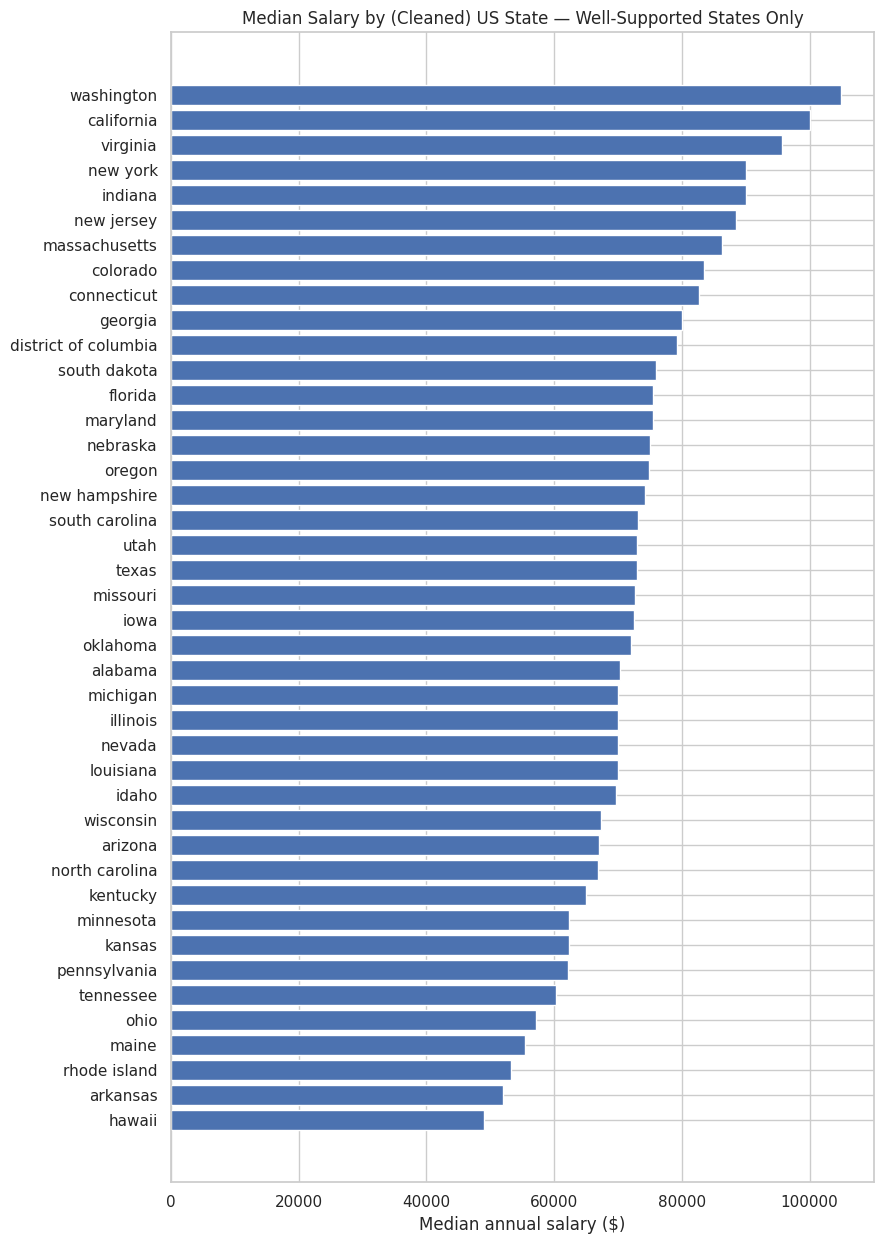

In [64]:
fig, ax = plt.subplots(figsize=(9, max(3, 0.3 * len(well_supported_clean))))
ordered = well_supported_clean.sort_values("median")
ax.barh(ordered.index, ordered["median"], color="#4C72B0")
ax.set_xlabel("Median annual salary ($)")
ax.set_title("Median Salary by (Cleaned) US State — Well-Supported States Only")
plt.tight_layout()
plt.show()

**Decision:** `company_state_clean` (and `company_country_clean`) replace
the raw `company_state` / `company_country` columns as CORE categorical
features going into model experimentation. The transformation and
decision-artifact tables from Sections 25/26/31 are updated below to
reflect this.

In [65]:
# Update the transformation decision table entries for geography
transform_table.loc[transform_table["feature"] == "company_state", "feature"] = "company_state_clean"
transform_table.loc[transform_table["feature"] == "company_state_clean", "recommended_transformation"] = (
    "Normalize via normalize_us_state() BEFORE OneHotEncoder(handle_unknown='ignore')"
)
transform_table.loc[transform_table["feature"] == "company_country", "feature"] = "company_country_clean"
transform_table.loc[transform_table["feature"] == "company_country_clean", "recommended_transformation"] = (
    "Normalize via normalize_country() BEFORE OneHotEncoder(handle_unknown='ignore')"
)

# Update the core feature set
CORE_CATEGORICAL = [f if f not in ("company_state", "company_country")
                     else f + "_clean" for f in CORE_CATEGORICAL]

# Update the machine-readable decision artifact and re-save it
decision_artifact["core_features"] = CORE_TEXT + CORE_CATEGORICAL + CORE_DERIVED_NUMERIC
decision_artifact["categorical_features"] = CORE_CATEGORICAL + OPTIONAL_CATEGORICAL
decision_artifact["transformations"]["company_state_clean"] = (
    "normalize_us_state(company_state, company_country) then OneHotEncoder(handle_unknown='ignore')"
)
decision_artifact["transformations"]["company_country_clean"] = (
    "normalize_country(company_country) then OneHotEncoder(handle_unknown='ignore')"
)
decision_artifact["transformations"].pop("company_state", None)
decision_artifact["transformations"].pop("company_country", None)
decision_artifact["geography_fix_applied"] = True
decision_artifact["geography_fix_notes"] = (
    "company_state raw cardinality (US rows) reduced from "
    f"{train.loc[us_mask, 'company_state'].nunique()} to {train.loc[us_mask, 'company_state_clean'].nunique()} "
    "via deterministic normalize_us_state(); see Section 32."
)

try:
    with open(OUTPUT_PATH, "w") as f:
        json.dump(decision_artifact, f, indent=2)
    print(f"Updated decision artifact saved to: {OUTPUT_PATH.resolve()}")
except OSError as e:
    print(f"Could not re-save artifact (non-fatal): {e}")

print()
print("Updated CORE_CATEGORICAL:", CORE_CATEGORICAL)

Updated decision artifact saved to: /content/artifacts/eda_reports/salary_preprocessing_audit.json

Updated CORE_CATEGORICAL: ['formatted_experience_level', 'company_state_clean', 'company_country_clean', 'top_industry']


**Next step for the pipeline (not done in this notebook):** move
`normalize_us_state()` / `normalize_country()` into the upstream salary
feature-engineering stage (or a shared `geography_utils` module) so
`train.parquet`, `validation.parquet`, `test.parquet`, and live product
inference all apply the *exact same* deterministic function — this
notebook only demonstrates and validates the fix on the training split,
per the ML safety rules governing this audit.